# Какой автобус выбрать? Моссовет → Азия Молл

**Практикум по статистике на реальных данных общественного транспорта Бишкека**

Вы на остановке «Моссовет», вам нужно в ТРЦ «Азия Молл». Туда идут два автобуса, и едут они разными улицами:

- **№118** — через «Сквер Тоголок Молдо» и проспект Манаса;
- **№169** — через ТРЦ «Вефа» и Ботанический сад.

Какой выбрать, если в запасе 15 минут? А если 20? Зависит ли ответ от времени суток? И что делать, если вы только подошли к остановке, а автобуса ещё нет?

Отвечать будем по данным: два месяца реальных движений автобусов, 25 июля — 22 сентября 2026 года. Это открытая лента системы мониторинга общественного транспорта мэрии Бишкека: та же, что показывает автобусы на карте в приложении. Она опубликована на Hugging Face как датасет `aiacademy-kg/bishkek-transport`.

## Постановка задачи

**Вопрос:** какой маршрут даёт больше шансов добраться от «Моссовета» до «Азия Молла» за отведённое время?

Работа состоит из двух частей, это один вопрос с двух сторон.

**Часть 1. Оба автобуса у остановки.** Сравниваем только время в пути $T$ — от проезда остановки «Моссовет» (A) до проезда остановки «Азия Молл» (B). Событие «успел» — это $\{T \le t\}$, где $t$ — запас времени в минутах. Его вероятность — функция распределения:

$$F_{118}(t) = P(T_{118} \le t), \qquad F_{169}(t) = P(T_{169} \le t).$$

Сравниваем, например, $F_{118}(15)$ и $F_{169}(15)$, потом другие запасы времени и разные часы. Возможно, один маршрут лучше почти всегда. Возможно, выбор зависит от времени суток и от того, насколько сильно вы боитесь опоздать. Это и должен показать анализ.

**Часть 2. Человек на остановке.** Вы только что подошли, автобуса нет. Полное время — это ожидание плюс поездка, $W + T$, и ожидание тоже случайно. Разберёмся, сколько приходится ждать, почему ждать приходится дольше, чем кажется, и меняется ли рекомендация, когда ожидание учтено.

**Что сдаёте:** этот ноутбук с решёнными заданиями и две короткие записки (по 5–7 предложений) — вывод части 1 и вывод части 2. В записке должно быть: какое событие вы изучали, какие доли получили, что говорит модель и почему она расходится с данными, к каким поездкам относится вывод. Одного графика или одного числа недостаточно.

## На что опирается работа

| Что используем | Где в работе | Занятие |
|---|---|---|
| Вектор, длина вектора (норма), расстояние | координаты в метрах, шаг автобуса между двумя отметками | 1 |
| Скалярное произведение, проекция, косинус угла | проехал ли автобус остановку и в нужную ли сторону | 2 |
| Генеральная совокупность и выборка, единица наблюдения | что такое одна поездка, к каким поездкам относится вывод | 3 |
| Среднее, медиана, σ, квантили, IQR, боксплот, выбросы | описание времени в пути по часам | 4 |
| Вероятность как доля, распределения Бернулли и биномиальное | «успел или нет», сколько опозданий из 20 поездок | 5 |
| Плотность, CDF, нормальная модель, z-оценка, модель против данных | шанс успеть; где нормальная модель ошибается | 6 |
| **Новое:** эмпирическая функция распределения, моделирование случайного прихода (метод Монте-Карло), парадокс ожидания | части 1 и 2 | — |

Три формулы, которые понадобятся.

**Эмпирическая функция распределения** — доля поездок, уложившихся в $t$ минут:

$$\hat F(t) = \frac{\#\{i : T_i \le t\}}{n}.$$

Это та же CDF из занятия 6, только построенная прямо по наблюдениям, без модели.

**Проекция точки на отрезок** (часть 0). Автобус сделал шаг из точки $P$ в точку $Q$, остановка находится в точке $S$:

$$u = \frac{(S - P)\cdot(Q - P)}{\lVert Q - P \rVert^2}, \qquad d = \frac{\lvert (Q-P)_x (S-P)_y - (Q-P)_y (S-P)_x \rvert}{\lVert Q - P \rVert}.$$

Если $0 \le u < 1$ и $d$ мало, автобус на этом шаге проехал мимо остановки. Время проезда находится интерполяцией: $t_P + u\,(t_Q - t_P)$.

**Направление** — через косинус угла между шагом $\vec v$ и направлением остановки $\vec e$ (единичный вектор):

$$\cos \varphi = \frac{\vec v \cdot \vec e}{\lVert \vec v \rVert}.$$

## Как работать с ноутбуком

1. **Часть 0** готовит данные. Её достаточно запустить целиком: в Colab это «Среда выполнения → Выполнить все» или запуск ячеек до начала части 1. Занимает около минуты. Каждый шаг объяснён: если хотите понять, как из сырой ленты получается таблица поездок, читайте подряд.
2. На выходе части 0 появляются таблицы `trips`, `departures`, `day_info` и другие. Их описание — в конце части 0.
3. **Части 1 и 2** — задания. В ячейках с пометкой `# your code here` пишете код, в ячейках «Ваш вывод» — ответы словами.

Задания со звёздочкой (*) — дополнительные.

## Зависимости для локального запуска (раздел свёрнут)

В Google Colab ничего устанавливать не нужно: все библиотеки уже есть.

Для запуска на своём компьютере нужны Python 3.10 или новее и библиотеки:

```
pip install numpy pandas pyarrow matplotlib scipy huggingface_hub
```

- **Версии.** Проверено с pandas 2.2 и 3.0, numpy 2.0 и новее, matplotlib 3.10–3.11, scipy 1.14–1.18. Скорее всего, подойдут и более ранние версии, но нужны как минимум pandas 2.0 и matplotlib 3.6.
- **Интернет.** Нужен доступ к huggingface.co: ноутбук скачивает готовую выгрузку данных, около 21 МБ.
- **Запасной путь.** Если выгрузка недоступна, ноутбук соберёт её сам из исходной ленты датасета. Это около 3,7 ГБ скачивания и несколько минут работы. Результат сохранится рядом с ноутбуком в файле `mossovet_asia_mall_2026.zip`, и следующий запуск будет быстрым.
- **Архив в той же папке.** Если положить `mossovet_asia_mall_2026.zip` рядом с ноутбуком заранее, скачивание не понадобится.

# Часть 0. От сырой ленты к таблице поездок

Сырые данные — это не поездки, а отметки: каждые ~5 секунд лента сообщает, где находится каждый автобус. Чтобы получить время в пути, нужно:

1. загрузить отметки маршрутов №118 и №169 в районе между остановками;
2. убрать повторяющиеся отметки;
3. перевести координаты в метры;
4. составить из соседних отметок шаги-векторы;
5. найти моменты, когда автобус проезжал нужные остановки;
6. собрать поездки от A до B и проверить, что автобус ехал своим путём;
7. добавить календарь и проверить, насколько полны данные за каждый день.

### 0.1 Библиотеки и настройки

In [1]:
# Standard scientific stack; everything is preinstalled in Google Colab
import io
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from IPython.display import display

pd.set_option('display.width', 160)
pd.set_option('display.max_columns', 30)

TZ = 'Asia/Bishkek'                        # local time, UTC+6 all year round
COLORS = {118: '#2a78d6', 169: '#eb6834'}  # one colour per route in every chart
plt.rcParams.update({
    'figure.dpi': 110, 'font.size': 10, 'axes.titlesize': 11, 'axes.titlelocation': 'left',
    'axes.grid': True, 'grid.color': '#e1e0d9', 'grid.linewidth': 0.8,
    'axes.spines.top': False, 'axes.spines.right': False, 'axes.edgecolor': '#c3c2b7',
})

### 0.2 Загрузка данных

Исходный датасет большой: 372 млн строк за два месяца по всему городу. Для практикума заранее сделана выгрузка на 21 МБ. В неё вошли:

- `positions` — все строки ленты по автобусам №118 и №169 внутри прямоугольника вокруг обоих путей (около 3,3 × 2,9 км), местные даты 25.07–22.09.2026. Повторяющиеся строки оставлены намеренно: их уберём сами;
- `feed_gaps` — перерывы больше 2 минут, когда лента не записывалась вообще (по всем автобусам города);
- `streets` — отметки всех маршрутов в том же прямоугольнике за один будний день. Они служат фоном для карт: показывают улицы, по которым ходит транспорт;
- `stops` — справочник всех 1 501 остановки Бишкека.

Код выгрузки приведён в ячейке ниже: `build_extract` просто фильтрует исходные файлы ленты по номеру маршрута, типу транспорта (2 = автобус) и прямоугольнику. Если готовой выгрузки нет, ноутбук выполнит эту же функцию на исходных файлах.

In [2]:
# Where the data come from
REPO_ID = 'aiacademy-kg/bishkek-transport'             # the open dataset on Hugging Face
REVISION = '4aa20aab0b17f10b66af45a9ea04e4d5e61a9f6f'  # fixed snapshot of the dataset (23.09.2026)
EXTRACT_NAME = 'mossovet_asia_mall_2026.zip'           # the prepared extract, ~21 MB
EXTRACT_IN_REPO = 'practicum/' + EXTRACT_NAME          # its place in the dataset repository

# Extract builder: the same code produced the prepared zip
ROUTES = (118, 169)
VEHICLE_TYPE = 2                                             # 2 = bus
BBOX = {'lat': (42.850, 42.876), 'lng': (74.579, 74.619)}    # both paths plus ~600 m around
PERIOD_UTC = ('2026-07-24T18:00:00+00:00', '2026-09-22T18:00:00+00:00')  # local dates 25.07-22.09
GAP_S = 120                                                  # a longer pause between polls is a gap
STREETS_FILE = 'transport-20260916T071530Z.parquet'          # Wed 16.09.2026, 13:15-18:00 local
TABLES = ['positions', 'feed_gaps', 'streets', 'stops']


def build_extract(feed_files, stops_path):
    """Filter the raw feed files (tracking/*.parquet, in time order); returns a dict of DataFrames."""
    parts, polls, streets = [], [], None
    for path in feed_files:
        d = pd.read_parquet(path, columns=['ts', 'id', 'type', 'route', 'lat', 'lng'])
        polls.append(d['ts'].drop_duplicates())      # poll times of the whole city, to find gaps
        in_box = d['lat'].between(*BBOX['lat']) & d['lng'].between(*BBOX['lng'])
        ours = d['type'].eq(VEHICLE_TYPE) & d['route'].isin(ROUTES) & in_box
        parts.append(d.loc[ours, ['ts', 'id', 'route', 'lat', 'lng']])
        if Path(path).name == STREETS_FILE:          # all transit in the box: streets for the maps
            streets = (d.loc[in_box, ['lat', 'lng']].round(4).drop_duplicates()
                       .sort_values(['lat', 'lng']).reset_index(drop=True))

    positions = pd.concat(parts, ignore_index=True)
    t = pd.to_datetime(positions['ts'], format='ISO8601', utc=True)
    period = (t >= pd.Timestamp(PERIOD_UTC[0])) & (t < pd.Timestamp(PERIOD_UTC[1]))
    positions = positions[period].astype({'id': 'int32', 'route': 'int16'}).reset_index(drop=True)

    poll = pd.to_datetime(pd.concat(polls).drop_duplicates(), format='ISO8601', utc=True)
    poll = poll.sort_values().reset_index(drop=True)
    pause = poll.diff().dt.total_seconds()
    i = pause.index[pause > GAP_S]
    gaps = pd.DataFrame({'gap_start_utc': poll[i - 1].to_numpy(), 'gap_end_utc': poll[i].to_numpy()})
    in_period = (gaps['gap_end_utc'] > pd.Timestamp(PERIOD_UTC[0])) & (gaps['gap_start_utc'] < pd.Timestamp(PERIOD_UTC[1]))
    gaps = gaps[in_period].reset_index(drop=True)
    return {'positions': positions, 'feed_gaps': gaps, 'streets': streets, 'stops': pd.read_parquet(stops_path)}


def save_zip(tables, path):
    """All tables as parquet files inside one zip archive."""
    with zipfile.ZipFile(path, 'w', compression=zipfile.ZIP_STORED) as z:
        for name in TABLES:
            buffer = io.BytesIO()
            tables[name].to_parquet(buffer, index=False, compression='zstd')
            z.writestr(f'{name}.parquet', buffer.getvalue())


def load_zip(path):
    with zipfile.ZipFile(path) as z:
        return {name: pd.read_parquet(io.BytesIO(z.read(f'{name}.parquet'))) for name in TABLES}


def build_from_raw_feed():
    """Fallback: download the raw feed files of the period (~3.7 GB) and filter them."""
    from concurrent.futures import ThreadPoolExecutor
    from huggingface_hub import HfApi, hf_hub_download
    from huggingface_hub.utils import disable_progress_bars
    disable_progress_bars()
    names = sorted(f for f in HfApi().list_repo_files(REPO_ID, repo_type='dataset', revision=REVISION)
                   if f.startswith('tracking/') and f.endswith('.parquet'))
    # A file name holds the start time of the file; keep the files that overlap the period
    starts = pd.to_datetime([Path(f).stem.split('-')[1] for f in names], format='%Y%m%dT%H%M%SZ', utc=True)
    ends = list(starts[1:]) + [pd.Timestamp('2100-01-01', tz='UTC')]
    names = [f for f, s, e in zip(names, starts, ends)
             if s < pd.Timestamp(PERIOD_UTC[1]) and e > pd.Timestamp(PERIOD_UTC[0])]
    print(f'Скачиваю {len(names)} файлов исходной ленты (~3,7 ГБ), это займёт несколько минут...')
    download = lambda name: hf_hub_download(REPO_ID, name, repo_type='dataset', revision=REVISION)
    with ThreadPoolExecutor(max_workers=8) as pool:
        paths = list(pool.map(download, names))
    stops_path = hf_hub_download(REPO_ID, 'stops/stops.parquet', repo_type='dataset', revision=REVISION)
    print('Фильтрую файлы...')
    return build_extract(paths, stops_path)


def get_tables():
    """A local zip next to the notebook -> the prepared zip from Hugging Face -> rebuild from the raw feed."""
    local = Path(EXTRACT_NAME)
    if not local.exists():
        try:
            from huggingface_hub import hf_hub_download
            local = Path(hf_hub_download(REPO_ID, EXTRACT_IN_REPO, repo_type='dataset'))
        except Exception as error:
            print('Готовая выгрузка недоступна:', type(error).__name__)
            tables = build_from_raw_feed()
            save_zip(tables, EXTRACT_NAME)  # keep it next to the notebook for the next run
            return tables
    return load_zip(local)

In [3]:
tables = get_tables()
positions_raw = tables['positions']  # raw feed rows of routes 118 and 169 in the study area
stops = tables['stops']              # all stops of Bishkek
feed_gaps = tables['feed_gaps']      # pauses in the recording of the whole feed
streets = tables['streets']          # background for the maps

# One time unit for every timestamp keeps pandas 2 and pandas 3 consistent
for col in ['gap_start_utc', 'gap_end_utc']:
    feed_gaps[col] = feed_gaps[col].dt.as_unit('ns')
print('строк ленты:', len(positions_raw), '| остановок в справочнике:', len(stops), '| перерывов записи:', len(feed_gaps))

строк ленты: 2810880 | остановок в справочнике: 1501 | перерывов записи: 27


### 0.3 Как выглядит лента

In [4]:
positions_raw.head()

,ts,id,route,lat,lng
0,2026-07-24T22:42:08.699674+00:00,1850,169,42.856964,74.610309
1,2026-07-24T22:42:14.358208+00:00,1850,169,42.856964,74.610309
2,2026-07-24T22:42:20.005169+00:00,1850,169,42.856964,74.610309
3,2026-07-24T22:42:25.668854+00:00,1850,169,42.856964,74.610309
4,2026-07-24T22:42:31.292996+00:00,1850,169,42.856950,74.610308


Что означают столбцы:

- `ts` — момент опроса ленты, **UTC**. Лента опрашивалась каждые ~5 секунд. В одном опросе ~700 машин всего города, и у всех одно и то же `ts`.
- `id` — номер машины в ленте;
- `route` — номер маршрута;
- `lat`, `lng` — широта и долгота. Их уже «прижала» к линии маршрута сама система мониторинга, поэтому это не сырые GPS-координаты, а точки на линии маршрута.

Новая отметка появляется, когда автобус сдвинулся: примерно раз в 10–20 секунд движения или через ~110 м. В остальные опросы лента повторяет прежние координаты. Посмотрим на одну машину за три минуты:

In [5]:
three_minutes = positions_raw[positions_raw['ts'].between('2026-09-16T04:00', '2026-09-16T04:03')]  # 10:00–10:03 local
bus = three_minutes['id'].iloc[0]
three_minutes[three_minutes['id'] == bus]

,ts,id,route,lat,lng
2387522,2026-09-16T04:00:02.455660+00:00,1679,118,42.866923,74.606609
2387528,2026-09-16T04:00:08.236838+00:00,1679,118,42.866943,74.606089
2387534,2026-09-16T04:00:14.126198+00:00,1679,118,42.866943,74.606089
2387540,2026-09-16T04:00:20.197748+00:00,1679,118,42.866995,74.604808
2387546,2026-09-16T04:00:25.951489+00:00,1679,118,42.866995,74.604808
2387552,2026-09-16T04:00:36.003735+00:00,1679,118,42.867044,74.603580
2387558,2026-09-16T04:00:41.716499+00:00,1679,118,42.867044,74.603580
2387564,2026-09-16T04:00:47.504947+00:00,1679,118,42.867135,74.601309
2387570,2026-09-16T04:00:53.178833+00:00,1679,118,42.867135,74.601309
2387576,2026-09-16T04:00:58.892776+00:00,1679,118,42.867135,74.601309


In [6]:
print('машин по маршрутам:', positions_raw.groupby('route')['id'].nunique().to_dict())
print('первая и последняя строка (UTC):', positions_raw['ts'].min(), '...', positions_raw['ts'].max())

машин по маршрутам: {118: 23, 169: 20}
первая и последняя строка (UTC): 2026-07-24T22:42:08.699674+00:00 ... 2026-09-22T17:27:42.596233+00:00


### 0.4 Время и повторы

Переводим `ts` в дату-время и сортируем отметки каждой машины по времени. Строка, в которой та же машина стоит в той же точке, что и в предыдущей, ничего нового не сообщает, поэтому её убираем. Каждой новой отметке остаётся время её **первого** появления в ленте.

In [7]:
positions = positions_raw.copy()
positions['t'] = pd.to_datetime(positions['ts'], format='ISO8601', utc=True).dt.as_unit('ns')
positions = positions.sort_values(['id', 't'], kind='stable').reset_index(drop=True)

# A row repeats the previous one when the same bus on the same route has not moved
prev = positions.shift()
repeat = ((positions['id'] == prev['id']) & (positions['route'] == prev['route'])
          & (positions['lat'] == prev['lat']) & (positions['lng'] == prev['lng']))
print(f'повторяющихся строк: {repeat.mean():.1%}')
positions = positions[~repeat].drop(columns='ts').reset_index(drop=True)
print('осталось отметок:', len(positions))

повторяющихся строк: 64.5%
осталось отметок: 997385


Почти две трети строк — повторы. Если их не убрать, стоящий автобус выглядел бы «многократно отмеченным», а все счётчики оказались бы завышены.

### 0.5 Координаты в метрах

Считать расстояния в градусах неудобно: градус долготы на широте Бишкека короче градуса широты. На участке в несколько километров Землю можно считать плоской. Один градус широты — это $R \cdot \frac{\pi}{180} \approx 111$ км, один градус долготы — ещё умноженный на $\cos(\text{широта}) \approx 0{,}73$, то есть около 81 км. Начало координат поместим в остановку A: $x$ — метры на восток, $y$ — метры на север.

In [8]:
STOP_A, STOP_B = 31, 116   # «Моссовет» (southbound side) and «Азия Молл»
# Intermediate stops of each path, in travel order
PATH_STOPS = {118: [445, 1352, 1353, 1354, 114, 115],
              169: [32, 493, 494, 495, 496, 497]}

R = 6_371_000  # Earth radius, metres
LAT0, LNG0 = stops.set_index('id').loc[STOP_A, ['lat', 'lng']]


def to_xy(lat, lng):
    """Degrees -> metres east (x) and north (y) of stop A (flat approximation of a small area)."""
    x = np.deg2rad(np.asarray(lng) - LNG0) * R * np.cos(np.deg2rad(LAT0))
    y = np.deg2rad(np.asarray(lat) - LAT0) * R
    return x, y


positions['x'], positions['y'] = to_xy(positions['lat'], positions['lng'])

used = [STOP_A, STOP_B] + PATH_STOPS[118] + PATH_STOPS[169]
stops_used = stops.set_index('id').loc[used, ['name_ru', 'lat', 'lng', 'direction']].copy()
stops_used['x'], stops_used['y'] = to_xy(stops_used['lat'], stops_used['lng'])
stops_used['role'] = ['A', 'B'] + ['путь №118'] * 6 + ['путь №169'] * 6
print('от A до B по прямой:', round(np.hypot(*stops_used.loc[STOP_B, ['x', 'y']])), 'м')
stops_used.round(1)

от A до B по прямой: 2470 м


,name_ru,lat,lng,direction,x,y,role
id,,,,,,,
31,Моссовет,42.9,74.6,1,0.0,0.0,A
116,Азия Молл,42.9,74.6,1,-2003.4,-1444.8,B
445,Панфилова (ул. Боконбаева),42.9,74.6,3,-792.8,-152.0,путь №118
1352,Логвиненко,42.9,74.6,3,-1072.7,143.8,путь №118
1353,Сквер Тоголок Молдо,42.9,74.6,3,-1464.4,167.6,путь №118
1354,проспект Манаса,42.9,74.6,3,-1833.3,190.9,путь №118
114,Жоомарта Боконбаева (проспект Манаса),42.9,74.6,1,-1946.6,-118.5,путь №118
115,Госрегистр,42.9,74.6,1,-1985.0,-1002.9,путь №118
32,Кулатова,42.9,74.6,1,-49.1,-880.9,путь №169


### 0.6 Шаги автобуса — векторы

Две соседние отметки одной машины — точки $P$ и $Q$. Вектор $\vec v = Q - P$ — это шаг автобуса, его длина $\lVert \vec v \rVert$ — пройденные метры. Оставляем обычные шаги: та же машина на том же маршруте, пауза не больше 5 минут, длина от 1 до 300 м. Более длинные «прыжки» — это обрывы связи, а не движение.

In [9]:
# Next mark of the same bus: together with the current one it forms the step vector
nxt = positions.groupby('id')[['t', 'x', 'y', 'route']].shift(-1)
steps = pd.DataFrame({
    'id': positions['id'], 'route': positions['route'],
    't0': positions['t'], 't1': nxt['t'],
    'x0': positions['x'], 'y0': positions['y'],
    'dx': nxt['x'] - positions['x'], 'dy': nxt['y'] - positions['y'],
})
steps['length_m'] = np.hypot(steps['dx'], steps['dy'])        # norm of the step vector
steps['dt_s'] = (steps['t1'] - steps['t0']).dt.total_seconds()

ordinary = ((nxt['route'] == positions['route']) & (steps['dt_s'] > 0) & (steps['dt_s'] <= 300)
            & steps['length_m'].between(1, 300))
print(f'шагов: {len(steps)}, из них обычных: {ordinary.mean():.1%}')
steps = steps[ordinary].reset_index(drop=True)
steps[['length_m', 'dt_s']].describe(percentiles=[.1, .5, .9, .99]).round(1)

шагов: 997385, из них обычных: 97.6%


,length_m,dt_s
count,973452.0,973452.0
mean,65.9,17.7
std,41.6,18.1
min,1.0,5.4
10%,13.8,5.7
50%,61.9,11.5
90%,109.0,37.7
99%,201.3,85.8
max,300.0,299.9


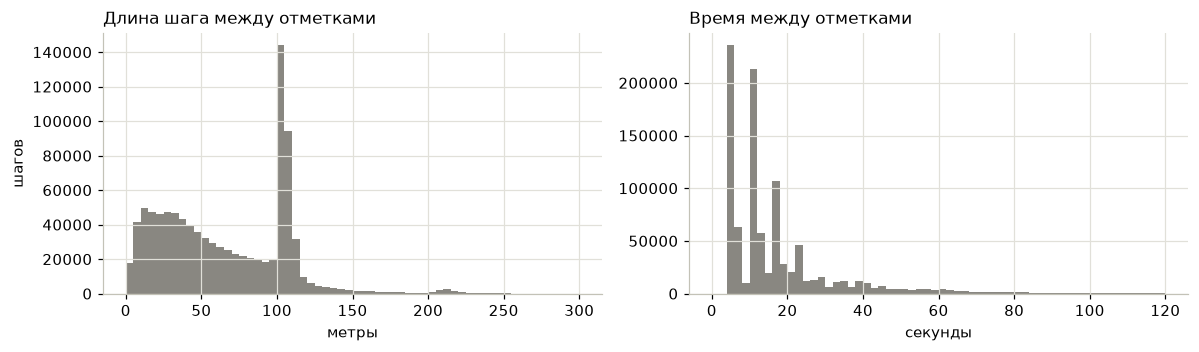

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.3))
axes[0].hist(steps['length_m'], bins=np.arange(0, 301, 5), color='#898781')
axes[0].set(title='Длина шага между отметками', xlabel='метры', ylabel='шагов')
axes[1].hist(steps['dt_s'], bins=np.arange(0, 121, 2), color='#898781')
axes[1].set(title='Время между отметками', xlabel='секунды')
plt.tight_layout()
plt.show()

Девять шагов из десяти не длиннее ~110 м: бортовое устройство отправляет отметку не реже чем через ~110 м пути, а более длинные шаги — это пропущенные отметки. Поэтому положение автобуса известно с точностью до шага, а момент проезда остановки приходится **вычислять** между двумя отметками. Этим и займёмся.

### 0.7 Проехал ли автобус остановку: скалярное произведение

Для каждого шага $P \to Q$ и остановки $S$:

1. **Проекция.** $u = \dfrac{(S-P)\cdot(Q-P)}{\lVert Q-P\rVert^2}$ показывает, где вдоль шага находится остановка: $u = 0$ — в точке $P$, $u = 1$ — в точке $Q$. Если $0 \le u < 1$, остановка лежит «между» отметками.
2. **Расстояние до линии шага** $d$ должно быть небольшим: не больше 30 м. Иначе автобус ехал по соседней улице.
3. **Направление.** У остановок есть противоположная сторона улицы. В справочнике у каждой остановки записано поле `direction` — код от 1 до 8, направление движения, которое она обслуживает: 1 — на юг, 3 — на запад, 5 — на север, 7 — на восток, чётные коды — диагонали. Переводим код в единичный вектор $\vec e$ и требуем, чтобы $\cos\varphi = \dfrac{\vec v\cdot\vec e}{\lVert\vec v\rVert} \ge \cos 50^\circ$. Иначе это встречный автобус на другой стороне улицы.
4. **Время проезда** — линейная интерполяция: $t = t_P + u\,(t_Q - t_P)$.

Проверяем все шаги сразу, это векторные операции pandas/numpy без циклов по строкам.

In [11]:
# Stop `direction` code (1–8) -> travel heading it serves, degrees clockwise from north
STOP_HEADING = {1: 180, 2: 225, 3: 270, 4: 315, 5: 0, 6: 45, 7: 90, 8: 135}


def stop_passages(steps, stop_id, radius_m=30, max_angle_deg=50):
    """Moments when buses pass the stop while moving in the stop's direction."""
    s = stops_used.loc[stop_id]
    px, py = s['x'] - steps['x0'], s['y'] - steps['y0']                    # vector P -> S
    u = (px * steps['dx'] + py * steps['dy']) / steps['length_m'] ** 2      # projection: dot product / |PQ|^2
    dist = (steps['dx'] * py - steps['dy'] * px).abs() / steps['length_m']  # distance from S to the line PQ
    heading = np.deg2rad(STOP_HEADING[s['direction']])
    ex, ey = np.sin(heading), np.cos(heading)                               # unit vector of the stop direction
    cos_angle = (steps['dx'] * ex + steps['dy'] * ey) / steps['length_m']
    hit = (u >= 0) & (u < 1) & (dist <= radius_m) & (cos_angle >= np.cos(np.deg2rad(max_angle_deg)))
    g = steps[hit]
    return pd.DataFrame({
        'id': g['id'], 'route': g['route'], 'stop_id': stop_id,
        't': g['t0'] + (g['t1'] - g['t0']) * u[hit],   # linear interpolation in time
        'bracket_s': g['dt_s'],                         # time between the two marks = uncertainty of t
        'dist_m': dist[hit],
    })


passages = pd.concat([stop_passages(steps, s) for s in stops_used.index], ignore_index=True)

# A slow bus can be caught on two neighbouring steps: keep one mark per visit, the closest one
passages = passages.sort_values(['id', 'stop_id', 't'])
new_visit = ((passages['id'] != passages['id'].shift()) | (passages['stop_id'] != passages['stop_id'].shift())
             | (passages['t'].diff() > pd.Timedelta(minutes=3)))
passages['visit'] = new_visit.cumsum()
passages = (passages.loc[passages.groupby('visit')['dist_m'].idxmin()]
            .drop(columns='visit').sort_values(['id', 't']).reset_index(drop=True))
print('проездов остановок:', len(passages))
passages.groupby(['stop_id', 'route']).size().unstack(fill_value=0)

проездов остановок: 47872


route,118,169
stop_id,,
31,3147,2591
32,0,2571
114,3136,0
115,3130,0
116,3169,2963
445,3088,0
493,0,2960
494,0,2962
495,0,2977


Каждый маршрут проезжает только свои промежуточные остановки, а A и B — оба. Так и должно быть. Посмотрим на один «пойманный» проезд вблизи остановки A:

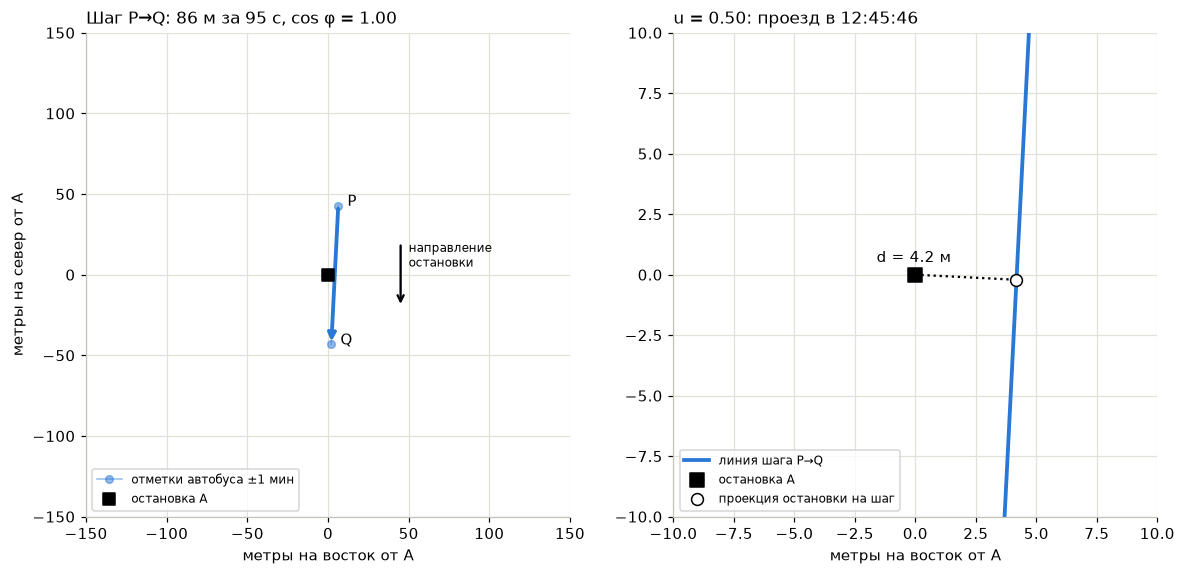

In [12]:
# The same geometry as in stop_passages(), for stop A only, to draw one clear example:
# a long step of route 118 on 16.09 (10–16 h) with stop A near its middle
A = stops_used.loc[STOP_A]
in_day = steps['t0'].between(pd.Timestamp('2026-09-16 10:00', tz=TZ), pd.Timestamp('2026-09-16 16:00', tz=TZ))
cand = steps[in_day & (steps['route'] == 118)].copy()
px, py = A['x'] - cand['x0'], A['y'] - cand['y0']
cand['u'] = (px * cand['dx'] + py * cand['dy']) / cand['length_m'] ** 2
cand['d'] = (cand['dx'] * py - cand['dy'] * px).abs() / cand['length_m']
h = np.deg2rad(STOP_HEADING[A['direction']])
cand['cos'] = (cand['dx'] * np.sin(h) + cand['dy'] * np.cos(h)) / cand['length_m']
hits = cand[cand['u'].between(0.3, 0.7) & (cand['d'] <= 30) & (cand['cos'] >= np.cos(np.deg2rad(50)))]
typical = hits[hits['d'].between(3, 6)]             # a typical distance from the stop to the line
step = (typical if len(typical) else hits).nlargest(1, 'length_m').iloc[0]
t_pass = step['t0'] + (step['t1'] - step['t0']) * step['u']
near = positions[(positions['id'] == step['id'])
                 & positions['t'].between(t_pass - pd.Timedelta(seconds=60), t_pass + pd.Timedelta(seconds=60))]
P = np.array([step['x0'], step['y0']])
Q = P + np.array([step['dx'], step['dy']])
S = np.array([A['x'], A['y']])
proj = P + step['u'] * (Q - P)                     # the point of the step closest to the stop

fig, (ax, zoom) = plt.subplots(1, 2, figsize=(11, 5.2))
# Left: the step among the bus marks
ax.plot(near['x'], near['y'], '-o', color=COLORS[118], ms=5, lw=1, alpha=0.5, label='отметки автобуса ±1 мин')
ax.annotate('', xy=Q, xytext=P, arrowprops=dict(arrowstyle='->', lw=2.5, color=COLORS[118]))
for name, point in [('P', P), ('Q', Q)]:
    ax.annotate(name, point, xytext=(6, 0), textcoords='offset points')
ax.scatter(*S, marker='s', s=70, color='black', zorder=5, label='остановка A')
h = np.deg2rad(STOP_HEADING[A['direction']])
ax.annotate('', xy=(S[0] + 45 + 40 * np.sin(h), S[1] + 20 + 40 * np.cos(h)), xytext=(S[0] + 45, S[1] + 20),
            arrowprops=dict(arrowstyle='->', lw=1.5, color='black'))
ax.annotate('направление\nостановки', (S[0] + 50, S[1] + 5), fontsize=8)
ax.set_aspect('equal')
ax.set(xlim=(-150, 150), ylim=(-150, 150), xlabel='метры на восток от A', ylabel='метры на север от A',
       title=f"Шаг P→Q: {step['length_m']:.0f} м за {step['dt_s']:.0f} с, cos φ = {step['cos']:.2f}")
ax.legend(loc='lower left', fontsize=8)

# Right: a close-up of the stop, where the projection and the distance d are visible
direction = (Q - P) / step['length_m']
line = np.array([proj - 12 * direction, proj + 12 * direction])
zoom.plot(line[:, 0], line[:, 1], color=COLORS[118], lw=2.5, label='линия шага P→Q')
zoom.scatter(*S, marker='s', s=90, color='black', zorder=5, label='остановка A')
zoom.scatter(*proj, s=60, color='white', edgecolor='black', zorder=6, label='проекция остановки на шаг')
zoom.plot([S[0], proj[0]], [S[1], proj[1]], ':', color='black')
zoom.annotate(f"d = {step['d']:.1f} м", (S + proj) / 2, xytext=(-10, 10), textcoords='offset points', ha='right')
zoom.set_aspect('equal')
zoom.set(xlim=(S[0] - 10, S[0] + 10), ylim=(S[1] - 10, S[1] + 10), xlabel='метры на восток от A',
         title=f"u = {step['u']:.2f}: проезд в {t_pass.tz_convert(TZ):%H:%M:%S}")
zoom.legend(loc='lower left', fontsize=8)
plt.tight_layout()
plt.show()

Шаг автобуса смотрит в ту же сторону, что и направление остановки ($\cos\varphi$ близок к 1), проекция остановки попала внутрь шага ($0 \le u < 1$), расстояние до линии шага — несколько метров. Значит, это проезд, и его время лежит между отметками $P$ и $Q$ в доле $u$ от их промежутка.

Расстояние $d$ почти всегда мало: лента «прижимает» отметки к линии маршрута, а остановки стоят у той же линии. Порог в 30 м нужен, чтобы не засчитать автобус с соседней параллельной улицы.

Обратите внимание и на время шага. Если автобус стоял на остановке, между отметками $P$ и $Q$ проходит больше времени, и момент проезда известен менее точно: интерполяция считает, что автобус ехал равномерно. Длительность шага сохраняем в столбце `bracket_s` — это и есть неопределённость момента проезда.

### 0.8 Поездки от A до B

Поездка — это проезд машиной остановки A и **следующий** проезд той же машиной остановки B. Условия:

- B не позже чем через 90 минут после A, и между ними машина не проезжала A ещё раз;
- машина ехала **своим** путём: проехала хотя бы 4 из 6 промежуточных остановок своего маршрута (60%). Это отсекает объезды и редкие рейсы по другой схеме;
- во время поездки лента записывалась без перерывов (`feed_gaps`).

Время в пути: $T = t_B - t_A$, в минутах.

In [13]:
pa = passages[passages['stop_id'] == STOP_A].sort_values(['id', 't']).copy()
pa['next_a'] = pa.groupby('id')['t'].shift(-1)  # the same bus at A the next time
pa = pa.rename(columns={'t': 't_a', 'bracket_s': 'bracket_a_s'})[['id', 'route', 't_a', 'next_a', 'bracket_a_s']]
pb = passages[passages['stop_id'] == STOP_B].rename(columns={'t': 't_b', 'bracket_s': 'bracket_b_s'})
pb = pb[['id', 'route', 't_b', 'bracket_b_s']]

# For every pass of A: the first later pass of B by the same bus, at most 90 min later
trips = pd.merge_asof(pa.sort_values('t_a'), pb.sort_values('t_b'), left_on='t_a', right_on='t_b',
                      by=['id', 'route'], direction='forward', tolerance=pd.Timedelta(minutes=90))
reached = trips['t_b'].notna() & (trips['next_a'].isna() | (trips['t_b'] < trips['next_a']))
print(f'проездов A: {len(trips)}, из них дошли до B: {reached.mean():.1%}')
trips = trips[reached].drop(columns='next_a').sort_values('t_a').reset_index(drop=True)


def passed_between(trips, stop_id):
    """True where the bus passed stop_id after A and before B on that trip."""
    ps = passages.loc[passages['stop_id'] == stop_id, ['id', 't']].rename(columns={'t': 't_s'}).sort_values('t_s')
    m = pd.merge_asof(trips[['id', 't_a', 't_b']].reset_index().sort_values('t_a'), ps,
                      left_on='t_a', right_on='t_s', by='id', direction='forward')
    return pd.Series((m['t_s'] <= m['t_b']).to_numpy(), index=m['index']).sort_index()


trips['path_share'] = np.nan
for route, path in PATH_STOPS.items():
    idx = trips.index[trips['route'] == route]
    trips.loc[idx, 'path_share'] = pd.concat([passed_between(trips.loc[idx], s) for s in path], axis=1).mean(axis=1)
print('доля пройденных промежуточных остановок своего пути:')
display(trips.groupby('route')['path_share'].value_counts().unstack(fill_value=0))

проездов A: 5738, из них дошли до B: 98.3%
доля пройденных промежуточных остановок своего пути:


path_share,0.000000,0.166667,0.500000,0.666667,0.833333,1.000000
route,,,,,,
118,14,2,6,12,43,2994
169,2,0,1,9,90,2465


In [14]:
trips['minutes'] = (trips['t_b'] - trips['t_a']).dt.total_seconds() / 60


def overlaps_gap(start, end):
    """True where the interval [start, end] overlaps a pause in the feed recording."""
    mask = np.zeros(len(start), dtype=bool)
    for gap in feed_gaps.itertuples():
        mask |= ((start < gap.gap_end_utc) & (end > gap.gap_start_utc)).to_numpy()
    return mask


off_path = trips['path_share'] < 0.6
in_gap = overlaps_gap(trips['t_a'], trips['t_b'])
print('не своим путём:', off_path.sum(), '| во время перерыва записи:', in_gap.sum())
trips = trips[~off_path & ~in_gap].reset_index(drop=True)
print('поездок:', len(trips))
trips[['route', 'id', 't_a', 't_b', 'minutes', 'path_share']].head()

не своим путём: 25 | во время перерыва записи: 17
поездок: 5599


,route,id,t_a,t_b,minutes,path_share
0,118,1688,2026-07-25 00:19:52.111570893+00:00,2026-07-25 00:31:44.145523453+00:00,11.867233,1.0
1,169,1903,2026-07-25 00:20:06.171876425+00:00,2026-07-25 00:27:16.759524280+00:00,7.176461,1.0
2,169,1614,2026-07-25 00:29:53.846872895+00:00,2026-07-25 00:37:05.252886541+00:00,7.190100,1.0
3,118,1676,2026-07-25 00:35:04.441689660+00:00,2026-07-25 00:45:00.858996662+00:00,9.940288,1.0
4,169,1230,2026-07-25 00:41:49.301688502+00:00,2026-07-25 00:50:10.094387388+00:00,8.346545,1.0


### 0.9 Календарь и полнота данных

Добавляем местное время отправления от A и признаки дня:

- `day_type` — будний, выходной или праздник. 31 августа — День независимости: это понедельник, но не обычный будний день;
- `season` — «лето» (до 31.08) или «сентябрь»: с 1 сентября начинается учебный год, и движение в городе меняется;
- `window` — окно дня: 07–10, 10–16, 16–20.

Затем проверим, **полны ли данные за каждый день**. Если в какой-то день автобусов в ленте заметно меньше обычного, это не значит, что они не ходили. Возможно, их не записала лента. Правило такое: день полный, если у обоих маршрутов проездов остановки A за 7–20 часов не меньше 75% от медианы для дней того же типа (будни или выходные).

In [15]:
HOLIDAYS = {'2026-08-31': 'День независимости'}
WINDOWS = {'07–10': (7, 10), '10–16': (10, 16), '16–20': (16, 20)}


def add_calendar(df):
    """Local departure time from A and calendar features."""
    local = df['t_a'].dt.tz_convert(TZ)
    df['dep_local'] = local
    df['date'] = local.dt.strftime('%Y-%m-%d')
    df['weekday'] = local.dt.dayofweek                          # 0 = Monday
    df['hour'] = local.dt.hour
    df['dep_hour'] = local.dt.hour + local.dt.minute / 60      # 8.5 = 08:30
    df['day_type'] = np.select([df['date'].isin(list(HOLIDAYS)), df['weekday'] >= 5],
                               ['праздник', 'выходной'], default='будний')
    df['season'] = np.where(df['date'] < '2026-09-01', 'лето', 'сентябрь')
    df['window'] = pd.cut(df['hour'], bins=[7, 10, 16, 20], right=False, labels=list(WINDOWS))
    return df


trips = add_calendar(trips)

# Every bus that passed A, whether or not the trip to B was recovered (needed in part 2)
departures = passages.loc[passages['stop_id'] == STOP_A, ['id', 'route', 't', 'bracket_s']]
departures = departures.rename(columns={'t': 't_a', 'bracket_s': 'bracket_a_s'})
departures = departures.merge(trips[['id', 't_a', 't_b', 'minutes']], on=['id', 't_a'], how='left')
departures['reached_b'] = departures['t_b'].notna()
departures = add_calendar(departures).sort_values('t_a').reset_index(drop=True)

# Completeness of every day: buses passing A between 7 and 20 h
all_dates = pd.date_range('2026-07-25', '2026-09-22', freq='D').strftime('%Y-%m-%d')
counts = (departures[departures['hour'].between(7, 19)].groupby(['date', 'route']).size()
          .unstack(fill_value=0).reindex(all_dates, fill_value=0))
day_info = pd.DataFrame({'buses_118': counts[118], 'buses_169': counts[169]})
day_info.index.name = 'date'
day_info['weekday'] = pd.to_datetime(day_info.index).dayofweek
kind = np.where(day_info['weekday'] >= 5, 'выходной', 'будний')
day_info['day_type'] = np.where(day_info.index.isin(list(HOLIDAYS)), 'праздник', kind)
for r in [118, 169]:
    typical = day_info.groupby(kind)[f'buses_{r}'].transform('median')
    day_info[f'share_{r}'] = (day_info[f'buses_{r}'] / typical).round(2)
day_info['day_ok'] = (day_info[['share_118', 'share_169']].min(axis=1) >= 0.75) & (day_info['day_type'] != 'праздник')

trips['day_ok'] = trips['date'].map(day_info['day_ok'])
departures['day_ok'] = departures['date'].map(day_info['day_ok'])
print('неполные дни и праздник:')
display(day_info[~day_info['day_ok']])

неполные дни и праздник:

,buses_118,buses_169,weekday,day_type,share_118,share_169,day_ok
date,,,,,,,
2026-08-01,22,19,5,выходной,0.47,0.48,False
2026-08-07,38,42,4,будний,0.73,1.06,False
2026-08-20,27,23,3,будний,0.52,0.58,False
2026-08-21,7,5,4,будний,0.13,0.13,False
2026-08-22,24,22,5,выходной,0.51,0.56,False
2026-08-30,47,17,6,выходной,1.00,0.43,False
2026-08-31,0,6,0,праздник,0.00,0.15,False
2026-09-01,7,4,1,будний,0.13,0.10,False


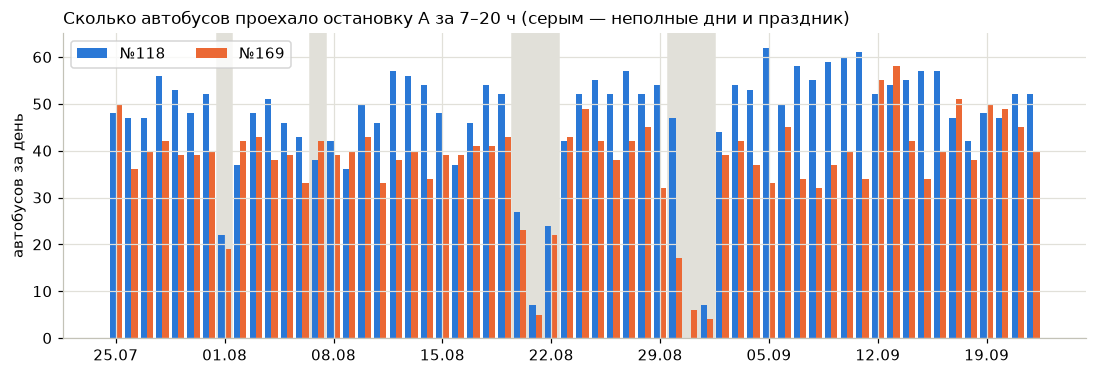

In [16]:
fig, ax = plt.subplots(figsize=(12, 3.6))
x = np.arange(len(day_info))
for offset, r in [(-0.2, 118), (0.2, 169)]:
    ax.bar(x + offset, day_info[f'buses_{r}'], width=0.4, color=COLORS[r], label=f'№{r}')
for i in np.flatnonzero(~day_info['day_ok'].to_numpy()):
    ax.axvspan(i - 0.5, i + 0.5, color='#e1e0d9', zorder=0)
ax.set_xticks(x[::7], [d[8:10] + '.' + d[5:7] for d in day_info.index[::7]])
ax.set(title='Сколько автобусов проехало остановку A за 7–20 ч (серым — неполные дни и праздник)',
       ylabel='автобусов за день')
ax.legend(loc='upper left', ncols=2)
plt.show()

Главные провалы — перерывы записи ленты: 1 августа и 20–22 августа (перерыв и восстановление). 31 августа — праздник, а 1 сентября лента записала лишь около десятой части обычного числа автобусов. Ещё в два дня, 7 и 30 августа, заметно меньше обычного было автобусов одного из маршрутов. Настоящий это перерыв в движении или пропуск записи, по этим данным не понять, поэтому такие дни тоже откладываем. **В заданиях используем только полные дни** (`day_ok`).

### 0.10 Первый взгляд на данные

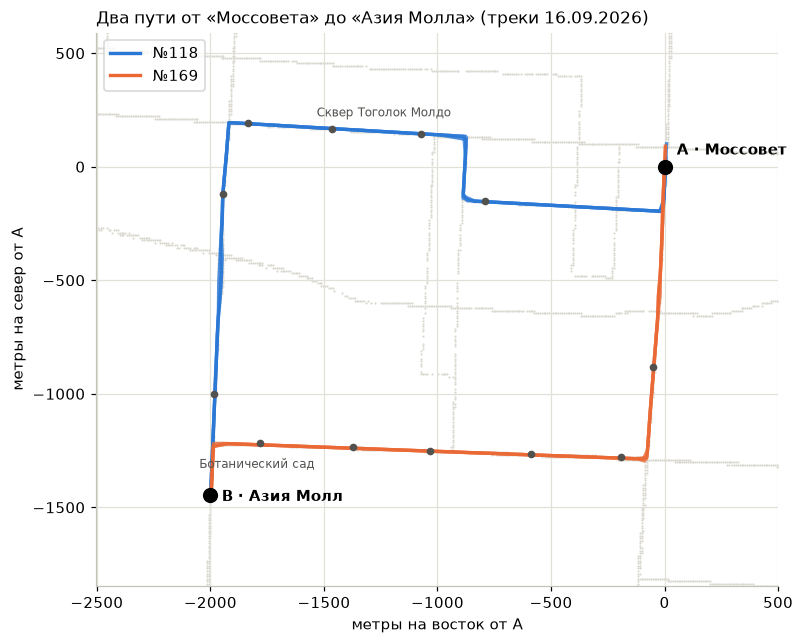

In [17]:
fig, ax = plt.subplots(figsize=(8, 7))
sx, sy = to_xy(streets['lat'], streets['lng'])
ax.scatter(sx, sy, s=2, color='#d9d7cf', linewidths=0)  # streets used by transit on one weekday

# Three typical trips of each route on one weekday, drawn from the cleaned marks
sample = trips[(trips['date'] == '2026-09-16') & trips['hour'].between(10, 15)].copy()
sample['gap_to_median'] = (sample['minutes'] - sample.groupby('route')['minutes'].transform('median')).abs()
for _, trip in sample.sort_values('gap_to_median').groupby('route').head(3).iterrows():
    track = positions[(positions['id'] == trip['id'])
                      & positions['t'].between(trip['t_a'] - pd.Timedelta(seconds=30), trip['t_b'] + pd.Timedelta(seconds=30))]
    ax.plot(track['x'], track['y'], color=COLORS[trip['route']], lw=2.2, alpha=0.8)
for r in [118, 169]:
    ax.plot([], [], color=COLORS[r], lw=2.2, label=f'№{r}')

on_path = stops_used[stops_used['role'].str.startswith('путь')]
ax.scatter(on_path['x'], on_path['y'], s=16, color='#52514e', zorder=3)
for sid, label, offset in [(STOP_A, 'A · Моссовет', (8, 8)), (STOP_B, 'B · Азия Молл', (8, -4)),
                           (1353, 'Сквер Тоголок Молдо', (-10, 8)), (497, 'Ботанический сад', (-40, -16))]:
    s = stops_used.loc[sid]
    big = sid in (STOP_A, STOP_B)
    if big:
        ax.scatter(s['x'], s['y'], s=80, color='black', zorder=4)
    ax.annotate(label, (s['x'], s['y']), xytext=offset, textcoords='offset points',
                fontsize=10 if big else 8, weight='bold' if big else 'normal', color='black' if big else '#52514e')
ax.set_aspect('equal')
ax.set(xlim=(stops_used['x'].min() - 500, stops_used['x'].max() + 500),
       ylim=(stops_used['y'].min() - 400, stops_used['y'].max() + 400),
       xlabel='метры на восток от A', ylabel='метры на север от A',
       title='Два пути от «Моссовета» до «Азия Молла» (треки 16.09.2026)')
ax.legend(loc='upper left')
plt.show()

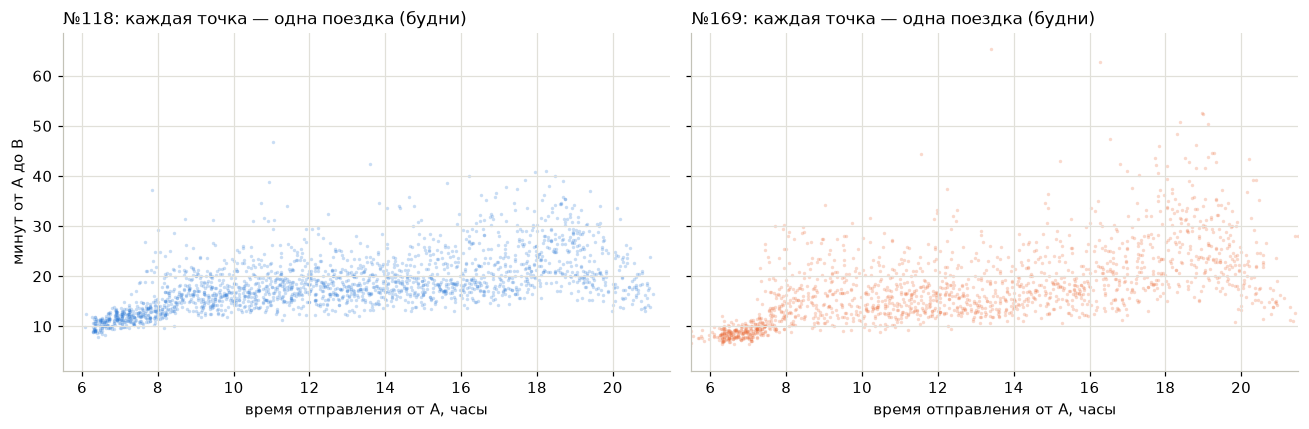

In [18]:
weekdays = trips[(trips['day_type'] == 'будний') & trips['day_ok']]
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, r in zip(axes, [118, 169]):
    g = weekdays[weekdays['route'] == r]
    ax.scatter(g['dep_hour'], g['minutes'], s=5, alpha=0.25, color=COLORS[r], linewidths=0)
    ax.set(title=f'№{r}: каждая точка — одна поездка (будни)', xlabel='время отправления от A, часы', xlim=(5.5, 21.5))
axes[0].set_ylabel('минут от A до B')
plt.tight_layout()
plt.show()

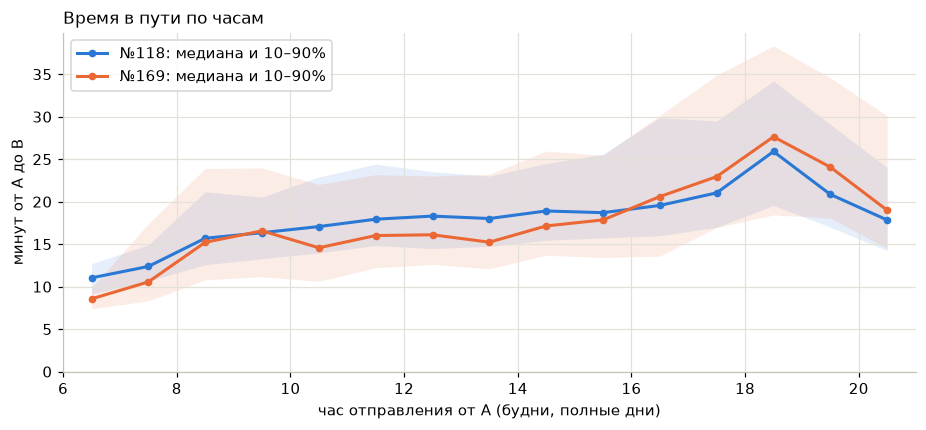

In [19]:
fig, ax = plt.subplots(figsize=(10, 4))
for r in [118, 169]:
    by_hour = (weekdays[weekdays['route'] == r].groupby('hour')['minutes']
               .agg(n='size', median='median', low=lambda s: s.quantile(0.1), high=lambda s: s.quantile(0.9)))
    by_hour = by_hour[by_hour['n'] >= 20]
    ax.fill_between(by_hour.index + 0.5, by_hour['low'], by_hour['high'], color=COLORS[r], alpha=0.12, linewidth=0)
    ax.plot(by_hour.index + 0.5, by_hour['median'], '-o', color=COLORS[r], lw=2, ms=4, label=f'№{r}: медиана и 10–90%')
ax.set(xlim=(6, 21), ylim=(0, None), xlabel='час отправления от A (будни, полные дни)', ylabel='минут от A до B',
       title='Время в пути по часам')
ax.legend(loc='upper left')
plt.show()

Медианы двух маршрутов близки, отличие — пара минут. Зато полосы разброса отличаются, особенно вечером. Для вопроса «успею ли» важна не середина, а весь разброс. Этим и займётся часть 1.

### 0.11 Итог: что у нас есть

**`trips`** — одна строка = одна поездка автобуса от A («Моссовет») до B («Азия Молл»):

| Столбец | Что это |
|---|---|
| `route` | маршрут: 118 или 169 |
| `id` | номер машины в ленте |
| `t_a`, `t_b` | проезд остановок A и B (UTC) |
| `minutes` | **время в пути** $T$, минуты |
| `dep_local` | время отправления от A, местное |
| `date`, `weekday`, `hour`, `dep_hour` | дата, день недели (0 = понедельник), час и час с долями |
| `day_type` | будний / выходной / праздник |
| `season` | лето (до 31.08) / сентябрь |
| `window` | окно дня: 07–10, 10–16, 16–20 (или пусто) |
| `day_ok` | день с полными данными |
| `path_share` | доля пройденных промежуточных остановок своего пути |
| `bracket_a_s`, `bracket_b_s` | время между отметками вокруг A и B, с (неопределённость момента проезда) |

**`departures`** — одна строка = один автобус, проехавший остановку A (для части 2): те же календарные столбцы и `t_a`, плюс `reached_b` (восстановлена ли поездка до B), `t_b` и `minutes` (пусто, если не восстановлена).

**`day_info`** — одна строка = один день: число автобусов каждого маршрута у A за 7–20 ч, доля от обычного, `day_ok`.

**`stops_used`** — остановки A, B и промежуточные. **`feed_gaps`** — перерывы записи ленты. **`positions`**, **`steps`**, **`passages`** — промежуточные таблицы части 0.

In [20]:
print('поездок:', trips.groupby('route').size().to_dict(),
      '| из них в будни с полными данными:', trips[(trips['day_type'] == 'будний') & trips['day_ok']].groupby('route').size().to_dict())
print('автобусов у A:', departures.groupby('route').size().to_dict(), '| полных будних дней:',
      int((day_info['day_ok'] & (day_info['day_type'] == 'будний')).sum()))

поездок: {118: 3043, 169: 2556} | из них в будни с полными данными: {118: 2101, 169: 1682}
автобусов у A: {118: 3147, 169: 2591} | полных будних дней: 37


# Часть 1. Оба автобуса у остановки: время в пути

Допустим, оба автобуса подходят к «Моссовету» одновременно, и вы выбираете, в какой сесть. Сравниваем время в пути $T$.

- Событие «успел» с запасом $t$ минут: $\{T \le t\}$.
- Его вероятность $F(t) = P(T \le t)$ оцениваем долей поездок: $\hat F(t)$.

Рабочие выборки ниже: будние дни с полными данными, в трёх окнах дня (`wd`), и выходные, 7–20 ч (`we`). «Оба варианта доступны» в этой части означает сравнение внутри одного окна одного типа дня: в эти часы ходят оба маршрута.

In [21]:
wd = trips[(trips['day_type'] == 'будний') & trips['day_ok'] & trips['window'].notna()].copy()
we = trips[(trips['day_type'] == 'выходной') & trips['day_ok'] & trips['hour'].between(7, 19)].copy()
print('будни:', wd.groupby('route').size().to_dict(), '| выходные:', we.groupby('route').size().to_dict())

будни: {118: 1895, 169: 1448} | выходные: {118: 699, 169: 646}


**Задание 1.1. Что считается наблюдением.**

1. Что описывает одна строка `trips`? Можно ли сказать, что это поездка пассажира? Чем они отличаются?
2. Сколько поездок каждого маршрута в каждом окне `wd`? За сколько дней?
3. Какие поездки не попали в выборку на шагах части 0? Перечислите фильтры. Мог ли какой-то из них сместить выборку, например убрать самые долгие поездки?
4. К каким поездкам будет относиться ваш вывод, то есть какова генеральная совокупность? Можно ли переносить вывод на зиму? На другие остановки? На маршрутки?

*Как считать:* `groupby(['window', 'route']).size()`, `nunique()` по датам.

*Самопроверка:* в `wd` около 1 900 поездок №118 и около 1 450 поездок №169.

In [22]:
display(wd.groupby(['window', 'route'], observed=True).size().unstack())
print('будних дней:', wd['date'].nunique(), '| выходных дней:', we['date'].nunique())

route,118,169
window,,
07–10,506,378
10–16,890,668
16–20,499,402


будних дней: 37 | выходных дней: 15


**Ваш вывод:**

**Для преподавателя.**

- **Строка — это рейс автобуса, а не поездка пассажира.** Ожидания в ней нет, и мы не знаем, стоял ли кто-то на остановке.
- **Объём:** 37 полных будних дней. Поездок №118 / №169 по окнам: утро около 506 / 378, день 890 / 668, вечер 499 / 402.
- **Фильтры части 0:** направление, ≤ 90 минут до B, путь ≥ 60% промежуточных остановок, без перерывов записи, только полные дни.
  - Порог 90 минут и перерывы записи в принципе могут отрезать самые долгие поездки. На практике поездок дольше часа почти нет, а у 98% проездов A поездка до B восстановлена.
- **Совокупность:** рейсы этих двух маршрутов между этими остановками, будни лета–сентября 2026 года.
  - Переносить на зиму нельзя: другая погода и дороги.
  - На другие остановки и маршрутки — тоже нельзя.

**Задание 1.2. Середина и разброс.**

1. Для каждого окна и маршрута посчитайте n, среднее, медиану, σ, квартили, IQR и 90-й перцентиль (p90) времени в пути.
2. Постройте боксплоты `minutes` по окнам, два маршрута рядом.
3. В каких окнах медианы близки, а разброс и хвосты разные?
4. Найдите выбросы по правилу 1,5·IQR (занятие 4). Сколько их? Выпишите три самые долгие поездки: дата, время отправления, минуты.
5. Удалять ли выбросы для нашего вопроса? Почему «выброс» здесь — не ошибка измерения, а как раз тот риск опоздать, который мы изучаем?

*Как считать:* `groupby([...])['minutes'].describe(percentiles=[.25, .5, .75, .9])`. Боксплоты — `ax.boxplot(...)` или `seaborn.boxplot`.

count  mean  std   min   25%   50%   75%   90%   max   IQR
window route                                                            
07–10  118    506.0  15.3  3.8   9.6  12.6  14.6  17.1  20.4  37.3   4.5
       169    378.0  14.7  5.4   6.5  10.5  13.3  17.4  22.7  34.2   6.9
10–16  118    890.0  19.0  4.2  11.2  16.3  18.2  20.8  24.2  46.8   4.5
       169    668.0  17.3  5.3   8.9  13.7  16.3  19.3  23.8  65.4   5.6
16–20  118    499.0  23.2  5.6  13.1  18.8  21.8  27.1  31.0  40.9   8.3
       169    402.0  25.1  8.0  10.9  19.4  23.5  29.6  35.1  62.7  10.2

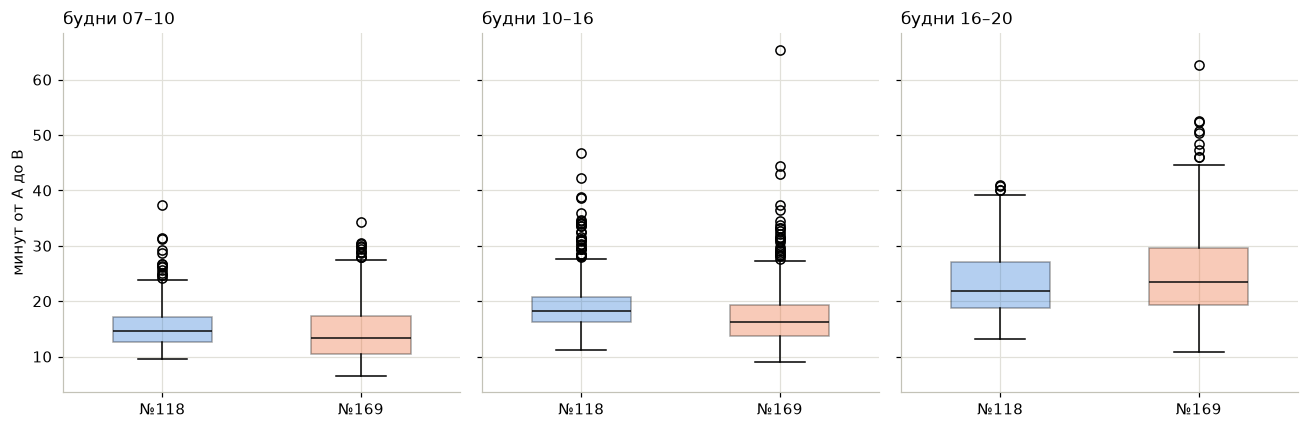

выбросов по 1,5·IQR:


route,118,169
window,,
07–10,14,12
10–16,32,26
16–20,4,9


,route,dep_local,minutes
983,169,2026-08-04 13:24:04.579748340+06:00,65.420295
2717,169,2026-08-24 16:17:12.160137101+06:00,62.691865
2737,169,2026-08-24 18:58:39.692411810+06:00,52.600744


In [23]:
table = (wd.groupby(['window', 'route'], observed=True)['minutes']
         .describe(percentiles=[.25, .5, .75, .9]).round(1))
table['IQR'] = table['75%'] - table['25%']
display(table)

fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=True)
for ax, w in zip(axes, WINDOWS):
    data = [wd.loc[(wd['window'] == w) & (wd['route'] == r), 'minutes'] for r in [118, 169]]
    box = ax.boxplot(data, patch_artist=True, widths=0.5, medianprops={'color': '#0b0b0b'})
    for patch, r in zip(box['boxes'], [118, 169]):
        patch.set(facecolor=COLORS[r], alpha=0.35)
    ax.set_xticks([1, 2], ['№118', '№169'])
    ax.set_title(f'будни {w}')
axes[0].set_ylabel('минут от A до B')
plt.tight_layout()
plt.show()


def iqr_outlier(x):
    q1, q3 = x.quantile([0.25, 0.75])
    return x > q3 + 1.5 * (q3 - q1)


flag = wd.groupby(['window', 'route'], observed=True)['minutes'].transform(iqr_outlier).astype(bool)
print('выбросов по 1,5·IQR:')
display(wd[flag].groupby(['window', 'route'], observed=True).size().unstack())
display(wd.nlargest(3, 'minutes')[['route', 'dep_local', 'minutes']])

**Ваш вывод:**

**Для преподавателя.**

- **Медианы** отличаются на 1–2 минуты: утром 14,6 / 13,3, днём 18,2 / 16,3, вечером 21,8 / 23,5.
- **Разброс у №169 больше:** σ 5,4 против 3,8 утром и 8,0 против 5,6 вечером. Вечером его p90 — 35 минут против 31 у №118.
- **Выбросы** — 1–4% поездок в каждой группе. Это реальные долгие поездки днём и вечером, до часа с лишним у №169, а не ошибки измерения. Удалять их нельзя, потому что вопрос как раз о риске опоздать.
- **Суть задания:** почувствовать, что у №169 медиана меньше, но хвост длиннее.

**Задание 1.3. Шанс успеть утром.**

1. Для окна 07–10 посчитайте $\hat F_{118}(15)$, $\hat F_{169}(15)$, $\hat F_{118}(20)$, $\hat F_{169}(20)$.
2. Какой автобус выбрать с запасом 15 минут? А с запасом 20?
3. Постройте обе эмпирические функции распределения на одном графике.
4. Найдите запас $t^*$, при котором ответ меняется: переберите $t$ с шагом 0,5 минуты и найдите, где разность $\hat F_{169}(t) - \hat F_{118}(t)$ меняет знак.
5. Объясните, как один маршрут может быть выгоднее при малом запасе, а другой — при большом. Что это говорит о форме распределений: центре, разбросе, хвосте?

*Как считать:* $\hat F(t)$ — это `(x <= t).mean()`. ECDF: отсортировать значения `np.sort(x)`, по оси y отложить `np.arange(1, n + 1) / n` и нарисовать `ax.step(...)`. В новых версиях matplotlib есть готовый `ax.ecdf(x)`.

F118(15) = 0.55    F169(15) = 0.61
F118(20) = 0.87    F169(20) = 0.84
кривые пересекаются около t* = 16.5 мин


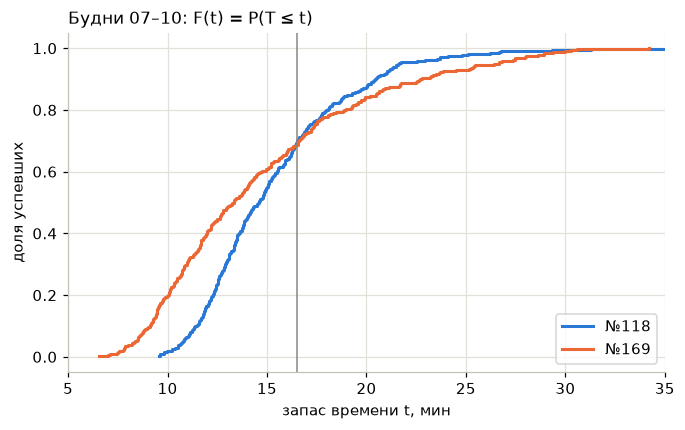

In [24]:
def F(x, t):
    """Empirical CDF at t: the share of trips not longer than t minutes."""
    return (np.asarray(x) <= t).mean()


morning = wd[wd['window'] == '07–10']
x118 = morning.loc[morning['route'] == 118, 'minutes']
x169 = morning.loc[morning['route'] == 169, 'minutes']
for t in [15, 20]:
    print(f'F118({t}) = {F(x118, t):.2f}    F169({t}) = {F(x169, t):.2f}')

grid = np.arange(8, 40.5, 0.5)
diff = np.array([F(x169, t) - F(x118, t) for t in grid])
t_star = grid[np.argmax(diff < 0)]  # the first budget at which №118 is ahead
print('кривые пересекаются около t* =', t_star, 'мин')

fig, ax = plt.subplots(figsize=(7, 4))
for r, x in [(118, x118), (169, x169)]:
    xs = np.sort(x)
    ax.step(xs, np.arange(1, len(xs) + 1) / len(xs), where='post', color=COLORS[r], lw=2, label=f'№{r}')
ax.axvline(t_star, color='#898781', lw=1)
ax.set(xlim=(5, 35), xlabel='запас времени t, мин', ylabel='доля успевших', title='Будни 07–10: F(t) = P(T ≤ t)')
ax.legend(loc='lower right')
plt.show()

**Ваш вывод:**

**Для преподавателя.**

- **Доли утром:**
  - с запасом 15 минут лучше №169: $\hat F$ ≈ 0,61 против 0,55;
  - с запасом 20 минут лучше №118: ≈ 0,87 против 0,84.
- **Точка смены:** кривые пересекаются около 16–16,5 минуты.
- **Почему так:** у №169 распределение сдвинуто влево — он чаще приезжает быстро, но у него длиннее правый хвост, то есть больше долгих поездок. №118 стабильнее.
- **Правильный ответ:** «зависит от того, насколько вы боитесь опоздать». Ответ «№169 быстрее» неверен.

**Задание 1.4. Таблица рекомендаций.**

1. Посчитайте $\hat F_r(t)$ для $t \in \{12, 15, 20, 25, 30\}$ в трёх окнах будних дней и в выходные (`we`).
2. Сведите в таблицу: окно × запас → какой маршрут лучше и на сколько процентных пунктов.
3. Разницу меньше ~5 п.п. считайте «примерно одинаково». Почему такой порог разумен? Оцените случайный разброс доли:
   - для доли $p$ по $n$ поездкам стандартная ошибка равна $\sqrt{p(1-p)/n}$ — это дисперсия биномиального распределения из занятия 5;
   - для разницы двух долей — $\sqrt{p_1(1-p_1)/n_1 + p_2(1-p_2)/n_2}$.

   Почему эта оценка скорее оптимистична? Подсказка: поездки одного и того же пробочного дня похожи друг на друга.

In [25]:
rows = []
parts = [(w, wd[wd['window'] == w]) for w in WINDOWS] + [('выходные 07–20', we)]
for name, part in parts:
    for t in [12, 15, 20, 25, 30]:
        f118 = F(part.loc[part['route'] == 118, 'minutes'], t)
        f169 = F(part.loc[part['route'] == 169, 'minutes'], t)
        n118, n169 = (part['route'] == 118).sum(), (part['route'] == 169).sum()
        se = np.sqrt(f118 * (1 - f118) / n118 + f169 * (1 - f169) / n169)
        rows.append({'окно': name, 'запас': t, 'F118': f118, 'F169': f169,
                     'разница 169−118, п.п.': 100 * (f169 - f118), 'ст. ошибка, п.п.': 100 * se})
advice = pd.DataFrame(rows)
advice['лучше'] = np.select([advice['разница 169−118, п.п.'] > 5, advice['разница 169−118, п.п.'] < -5],
                            ['№169', '№118'], default='примерно одинаково')
display(advice.round(2))

,окно,запас,F118,F169,"разница 169−118, п.п.","ст. ошибка, п.п.",лучше
0,07–10,12,0.17,0.41,24.14,3.02,№169
1,07–10,15,0.55,0.61,5.71,3.35,№169
2,07–10,20,0.87,0.84,-3.22,2.39,примерно одинаково
3,07–10,25,0.98,0.93,-4.97,1.47,примерно одинаково
4,07–10,30,0.99,0.99,-0.20,0.57,примерно одинаково
5,10–16,12,0.00,0.07,7.22,1.01,№169
6,10–16,15,0.13,0.37,24.39,2.17,№169
7,10–16,20,0.69,0.78,8.71,2.24,№169
8,10–16,25,0.92,0.92,-0.37,1.39,примерно одинаково
9,10–16,30,0.98,0.98,0.08,0.79,примерно одинаково


**Ваш вывод:**

**Для преподавателя.** Ожидаемая картина:

- **Утро:** при запасе ≤ 15 минут лучше №169, при 12 минутах — на 24 п.п. При 20–25 минутах немного лучше №118, на 3–5 п.п., на границе порога.
- **День:** №169 лучше при запасе ≤ 20 минут, на 7–24 п.п.; при 25 минутах и больше одинаково.
- **Вечер:** при запасе 20–30 минут лучше №118, на 7–10 п.п.
- **Выходные:** №169 лучше при малых запасах.

Стандартная ошибка разницы — до 3–3,5 п.п., поэтому порог 5 п.п. — это около полутора-двух ошибок. Оценка оптимистична: поездки одного дня зависимы, и настоящая неопределённость больше.

**Задание 1.5. Ловушка общей цифры.**

1. Посчитайте $\hat F_{118}(20)$ и $\hat F_{169}(20)$ сразу по всем будним поездкам `wd`, без разбиения на окна. Что «говорит» общая цифра?
2. Сравните с таблицей из 1.4. Как получилось, что общая разница почти нулевая, хотя внутри окон различия заметные?
3. Проверьте, одинаков ли состав выборок: какая доля поездок каждого маршрута приходится на каждое окно (`pd.crosstab(..., normalize='index')`)?
4. Если бы у одного маршрута было заметно больше поездок в «быстрые» утренние часы, что стало бы с общей цифрой? Почему сравнивать нужно при одинаковых условиях?

In [26]:
print('F(20) по всем будним поездкам 07–20:', {r: round(float(F(wd.loc[wd['route'] == r, 'minutes'], 20)), 3) for r in [118, 169]})
display(pd.crosstab(wd['route'], wd['window'], normalize='index').round(3))

F(20) по всем будним поездкам 07–20: {118: 0.651, 169: 0.657}


window,07–10,10–16,16–20
route,,,
118,0.267,0.470,0.263
169,0.261,0.461,0.278


**Ваш вывод:**

**Для преподавателя.**

- **Общая цифра:** $\hat F(20)$ ≈ 0,65 и 0,66, то есть «разницы нет». Но это результат **взаимного гашения**: днём №169 лучше на 9 п.п., вечером №118 лучше на 7 п.п.
- **Состав выборок почти одинаковый** (26/47/27% поездок по окнам), так что здесь не парадокс Симпсона, а сложение противоположных эффектов.
- **Если бы состав различался**, общая цифра дополнительно исказилась бы: маршрут с большей долей «быстрых» часов выглядел бы лучше.
- **Главный урок:** сравнивать нужно при одинаковых условиях.

**Задание 1.6. Нормальная модель: где она ошибается.**

1. Возьмите вечер (16–20). Для каждого маршрута оцените $\mu$ и $\sigma$.
2. Постройте гистограмму плотности (`density=True`) и кривую нормальной плотности $N(\mu, \sigma)$.
3. Сравните модель и данные для $P(T \le 20)$, $P(T > 30)$, $P(T > 35)$. По модели — `stats.norm.cdf` и `stats.norm.sf`, по данным — доля поездок. Посчитайте z-оценку для 35 минут.
4. Проверьте правило 68–95–99,7: какие доли поездок попадают в $\mu \pm 1\sigma$, $\pm 2\sigma$, $\pm 3\sigma$?
5. Какую вероятность **отрицательного** времени в пути даёт модель?
6. Где модель ошибается сильнее — в центре или в хвосте? Годится ли она для вопроса «успею ли с большим запасом»? Что лучше использовать вместо неё?

№118: P(T ≤ 20) данные 0.355, модель 0.286
      P(T > 30) данные 0.132, модель 0.114, z = 1.20
      P(T > 35) данные 0.038, модель 0.018, z = 2.09
      в μ±1σ, μ±2σ, μ±3σ: [0.671, 0.956, 0.996] | модель: P(T < 0) = 2.0e-05 | асимметрия 0.74
№169: P(T ≤ 20) данные 0.286, модель 0.262
      P(T > 30) данные 0.231, модель 0.270, z = 0.61
      P(T > 35) данные 0.107, модель 0.108, z = 1.24
      в μ±1σ, μ±2σ, μ±3σ: [0.736, 0.948, 0.988] | модель: P(T < 0) = 8.5e-04 | асимметрия 1.08


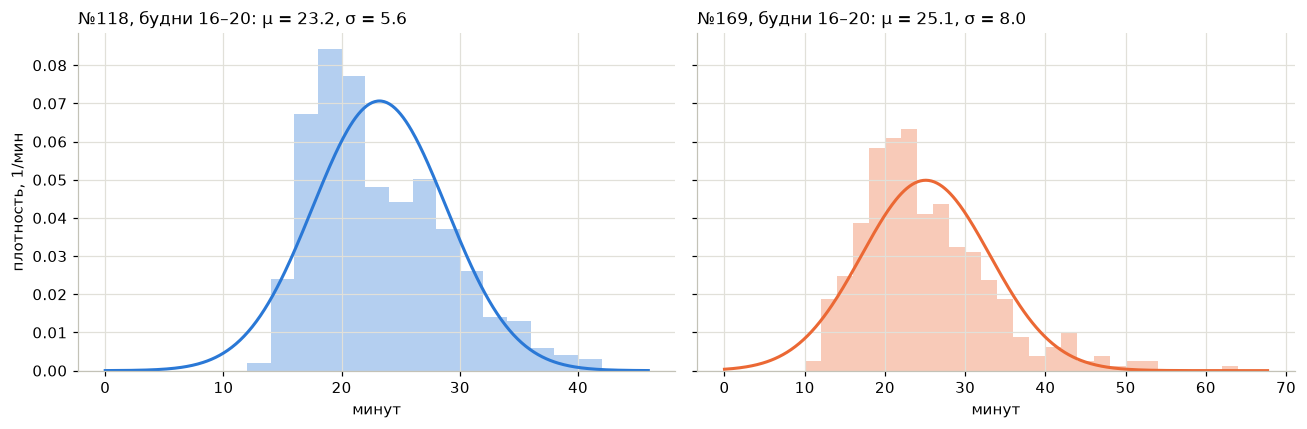

In [27]:
evening = wd[wd['window'] == '16–20']
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, r in zip(axes, [118, 169]):
    x = evening.loc[evening['route'] == r, 'minutes']
    mu, sd = x.mean(), x.std()
    grid = np.linspace(0, x.max() + 5, 400)
    ax.hist(x, bins=np.arange(0, x.max() + 2, 2), density=True, color=COLORS[r], alpha=0.35)
    ax.plot(grid, stats.norm.pdf(grid, mu, sd), color=COLORS[r], lw=2)
    ax.set(title=f'№{r}, будни 16–20: μ = {mu:.1f}, σ = {sd:.1f}', xlabel='минут')
    print(f'№{r}: P(T ≤ 20) данные {F(x, 20):.3f}, модель {stats.norm.cdf(20, mu, sd):.3f}')
    for t in [30, 35]:
        print(f'      P(T > {t}) данные {(x > t).mean():.3f}, модель {stats.norm.sf(t, mu, sd):.3f}, z = {(t - mu) / sd:.2f}')
    print('      в μ±1σ, μ±2σ, μ±3σ:', [round(float(((x - mu).abs() <= k * sd).mean()), 3) for k in (1, 2, 3)],
          f'| модель: P(T < 0) = {stats.norm.cdf(0, mu, sd):.1e} | асимметрия {stats.skew(x):.2f}')
axes[0].set_ylabel('плотность, 1/мин')
plt.tight_layout()
plt.show()

**Ваш вывод:**

**Для преподавателя.**

- **Центр:** правило 68–95–99,7 выполняется примерно, 67–74% / 95% / 99%.
- **Хвосты — главная ошибка модели.** Распределение скошено вправо, асимметрия около 0,7 у №118 и 1,1 у №169.
  - У №118 модель вдвое занижает $P(T > 35)$: 1,8% против 3,8%. Она же занижает $P(T \le 20)$: 29% против 35%.
  - У №169 при $\mu \pm 3\sigma$ за пределами оказывается 1,2% поездок против 0,3% по модели.
- **Отрицательное время:** модель даёт ему ненулевую вероятность, до ~$10^{-3}$ у №169. Это явный признак, что для времени в пути, которое не бывает отрицательным, модель — лишь приближение.
- **Для вопроса «успею ли с запасом»** важен хвост. Лучше пользоваться эмпирической функцией распределения.

**Задание 1.7. Лето и сентябрь.**

1. Разделите утренние поездки (07–10) по столбцу `season`: «лето» (до 31.08) и «сентябрь».
2. Повторите задание 1.3 для каждого периода: медианы, $\hat F(15)$, $\hat F(20)$, n.
3. Сохраняется ли вывод? Что изменилось с началом учебного года?
4. Представьте, что вы сделали выводы по лету и применили их в сентябре. Насколько точно летние доли предсказали сентябрьские? Почему прошлое распределение — не гарантия будущего?

In [28]:
rows = []
for season, part in morning.groupby('season'):
    for r in [118, 169]:
        x = part.loc[part['route'] == r, 'minutes']
        rows.append({'период': season, 'маршрут': r, 'n': len(x), 'медиана': x.median(), 'F(15)': F(x, 15), 'F(20)': F(x, 20)})
display(pd.DataFrame(rows).round(3))

,период,маршрут,n,медиана,F(15),F(20)
0,лето,118,299,14.107,0.589,0.920
1,лето,169,236,12.779,0.665,0.881
2,сентябрь,118,207,15.029,0.498,0.807
3,сентябрь,169,142,14.495,0.514,0.775


**Ваш вывод:**

**Для преподавателя.**

- **Сентябрь медленнее лета:** медианы выросли на 1–2 минуты, $\hat F(20)$ упала с ~0,9 до ~0,8.
- **Порядок сохранился:**
  - при запасе 20 минут №118 лучше в обоих периодах;
  - при запасе 15 минут №169 лучше, но в сентябре разница сжалась до 1–2 п.п.
- **Летние доли завышают сентябрьские** на 9–15 п.п. Условия изменились (учебный год), а прошлое распределение описывает прошлые условия.

**Задание 1.8\*. Парное сравнение.**

1. Для каждой поездки №169 найдите поездку №118 того же дня, отправившуюся от A не дальше ±10 минут. Подойдёт `pd.merge_asof(..., by='date', direction='nearest', tolerance=pd.Timedelta(minutes=10))`.
2. Для каждой пары посчитайте разницу $T_{169} - T_{118}$. В каком проценте пар №169 быстрее? Какова медиана разницы по окнам?
3. Почему такое сравнение честнее, чем сравнение всех поездок окна? Чего оно всё равно не учитывает?

In [29]:
a = wd[wd['route'] == 169].sort_values('t_a')
b = wd[wd['route'] == 118].sort_values('t_a')[['date', 't_a', 'minutes']].rename(columns={'t_a': 't_a_118', 'minutes': 'minutes_118'})
pairs = pd.merge_asof(a, b, left_on='t_a', right_on='t_a_118', by='date', direction='nearest',
                      tolerance=pd.Timedelta(minutes=10)).dropna(subset=['minutes_118'])
pairs['diff'] = pairs['minutes'] - pairs['minutes_118']
display(pairs.groupby('window', observed=True)['diff'].agg(
    pairs='size', share_169_faster=lambda d: (d < 0).mean(), median_diff='median').round(3))

,pairs,share_169_faster,median_diff
window,,,
07–10,365,0.625,-1.112
10–16,646,0.718,-2.167
16–20,346,0.460,0.750


**Ваш вывод:**

**Для преподавателя.**

- **Результат:** около 1 350 пар. №169 быстрее в ~62% пар утром и ~72% днём, вечером — только в ~46%.
- **Почему честнее:** пары почти одновременны, поэтому погода, пробка и день недели у них общие.
- **Чего не учитывает:** автобусы всё же разные, у них разное число пассажиров на остановках, и ±10 минут — не ноль.

**Задание 1.9\*. Двадцать поездок в месяц.**

1. Вы ездите утром 20 раз в месяц с запасом 20 минут. Опоздание — событие Бернулли с вероятностью $p = 1 - \hat F(20)$.
2. Сколько опозданий в среднем и какова дисперсия для каждого маршрута (биномиальная модель, занятие 5)? Какова вероятность опоздать 3 раза и больше (`stats.binom.sf`)?
3. Смоделируйте 10 000 «месяцев» (`rng.binomial`) и сравните с формулой.
4. Какое допущение биномиальной модели здесь сомнительно?

In [30]:
rng = np.random.default_rng(0)
for r, x in [(118, x118), (169, x169)]:
    p = 1 - F(x, 20)
    months = rng.binomial(20, p, size=10_000)
    print(f'№{r}: p = {p:.3f}; в среднем {20 * p:.2f} опозданий, дисперсия {20 * p * (1 - p):.2f}; '
          f'P(≥3) = {stats.binom.sf(2, 20, p):.3f}; модель: среднее {months.mean():.2f}, P(≥3) = {(months >= 3).mean():.3f}')

№118: p = 0.126; в среднем 2.53 опозданий, дисперсия 2.21; P(≥3) = 0.473; модель: среднее 2.53, P(≥3) = 0.476
№169: p = 0.159; в среднем 3.17 опозданий, дисперсия 2.67; P(≥3) = 0.636; модель: среднее 3.20, P(≥3) = 0.651


**Ваш вывод:**

**Для преподавателя.**

- **В среднем:** 2,5 опоздания из 20 у №118 и 3,2 у №169. Вероятность опоздать 3 раза и больше — около 47% и 64%.
- **Сомнительное допущение — независимость:** в пробочный день опаздывают все поездки сразу. Опоздания группируются по дням, поэтому реальная дисперсия числа опозданий за месяц больше биномиальной.

**Записка к части 1** (5–7 предложений). Если оба автобуса у остановки, какой выбрать при запасе 15 и 20 минут утром, днём и вечером? Приведите доли. Что показала нормальная модель и почему она расходится с данными? К каким поездкам относится вывод?

**Ваша записка:**

# Часть 2. Человек на остановке: ожидание плюс поездка

Теперь вы только что подошли к «Моссовету», и автобуса нет. Полное время до «Азия Молла»:

$$\text{полное время} = W + T,$$

где $W$ — ожидание автобуса. Ожидание тоже случайно: вы приходите в случайный момент, а автобусы ходят неравномерно.

**Допущения**, которые нужно повторить в записке:

1. **Случайный приход.** Пассажир приходит в случайный момент внутри окна дня (равномерно) и не смотрит приложение с картой автобусов.
2. **В любой автобус можно сесть.** Данных о заполненности нет.
3. **Учитываем только дошедшие автобусы.** Берём те, что доехали до «Азия Молла» своим путём (`reached_b`), — это около 97,5% проездов A. Остальные для нас «не пришли», и ожидание поэтому чуть завышено.
4. **Только полные будние дни.** Моменты прихода, после которых в течение часа лента не записывалась, отбрасываем: неизвестно, какие автобусы тогда пришли.
5. **Час ожидания.** Если нужный автобус не пришёл за 60 минут, пассажир считается не успевшим.

Ниже готовые инструменты. Разберите, что они делают, прежде чем пользоваться.

In [31]:
# Buses at A on complete weekdays whose trip to B was recovered
deps = departures[departures['reached_b'] & departures['day_ok'] & (departures['day_type'] == 'будний')]
deps = deps.sort_values('t_a').reset_index(drop=True)
DAYS = sorted(deps['date'].unique())
print('автобусов:', deps.groupby('route').size().to_dict(), '| дней:', len(DAYS))


def random_arrivals(h_from, h_to, n=20_000, seed=1):
    """n passengers: a random complete weekday and a uniform moment between h_from and h_to (local hours)."""
    rng = np.random.default_rng(seed)
    day = pd.to_datetime(pd.Series(rng.choice(DAYS, n))).dt.tz_localize(TZ)
    moment = day + pd.to_timedelta(rng.uniform(h_from * 3600, h_to * 3600, n), unit='s')
    moment = moment.dt.tz_convert('UTC').dt.as_unit('ns')
    # the hour after the arrival must be recorded, otherwise we cannot know which buses came
    moment = moment[~overlaps_gap(moment, moment + pd.Timedelta(minutes=60))]
    return moment.sort_values().reset_index(drop=True)


def next_bus(arrivals, buses, max_wait_min=60):
    """For every arrival moment: the first bus of `buses` that passes A at or after it.

    Returns arrival, t_a, t_b, route, wait_min (W) and total_min (W + T).
    If no bus comes within max_wait_min, the bus columns are empty (NaN / NaT).
    """
    left = pd.DataFrame({'arrival': arrivals})
    right = buses[['t_a', 't_b', 'route']].sort_values('t_a')
    m = pd.merge_asof(left, right, left_on='arrival', right_on='t_a', direction='forward',
                      tolerance=pd.Timedelta(minutes=max_wait_min))
    m['wait_min'] = (m['t_a'] - m['arrival']).dt.total_seconds() / 60
    m['total_min'] = (m['t_b'] - m['arrival']).dt.total_seconds() / 60
    return m


# Example: three passengers in the morning and the first bus of either route (times shown in local time)
example = next_bus(random_arrivals(7, 10, n=3, seed=5), deps)
for col in ['arrival', 't_a', 't_b']:
    example[col] = example[col].dt.tz_convert(TZ).dt.strftime('%d.%m %H:%M:%S')
example

автобусов: {118: 2101, 169: 1682} | дней: 37


,arrival,t_a,t_b,route,wait_min,total_min
0,27.07 07:09:42,27.07 07:10:00,27.07 07:20:22,118,0.305980,10.667260
1,04.09 08:32:45,04.09 08:42:29,04.09 08:58:27,169,9.735080,25.704269
2,11.09 07:51:26,11.09 07:56:49,11.09 08:11:55,169,5.377977,20.479236


**Задание 2.1. Как часто ходят автобусы.**

1. По таблице `deps` посчитайте интервалы $H$ между соседними автобусами у остановки A в трёх вариантах: только №118, только №169, «любой из двух» (общий поток).
2. Интервалы считаются внутри одного дня, не через ночь. Уберите те, что пересекают перерывы записи: `overlaps_gap(начало, конец)`.
3. По окнам дня посчитайте среднее, медиану, p90, максимум и коэффициент вариации $CV = \sigma / \text{среднее}$. Постройте гистограммы.
4. Какие интервалы вы видите: регулярные или «пачками»? Самый длинный интервал — это ошибка данных или реальность? Проверьте время и дату.
5. Почему средний интервал для «любого из двух» не равен половине интервала одного маршрута?

*Как считать:* `sort_values('t_a')`, затем `groupby('date')['t_a'].diff()`.

*Самопроверка:* днём в будни №118 проходит остановку в среднем примерно раз в четверть часа.

n   mean  median    p90     max    cv
      window                                          
№118  07–10    505  12.79   11.93  18.53   58.29  0.43
      10–16    888  14.88   14.43  22.19   60.72  0.40
      16–20    496  16.55   14.81  26.79   56.95  0.51
№169  07–10    378  16.67   14.83  26.92   75.93  0.51
      10–16    665  19.92   17.34  33.71   73.16  0.56
      16–20    399  21.30   17.97  38.55  103.95  0.65
любой 07–10    883   7.35    6.84  13.34   44.49  0.66
      10–16   1556   8.52    8.05  15.88   35.36  0.67
      16–20    898   9.43    8.48  18.38   43.31  0.71

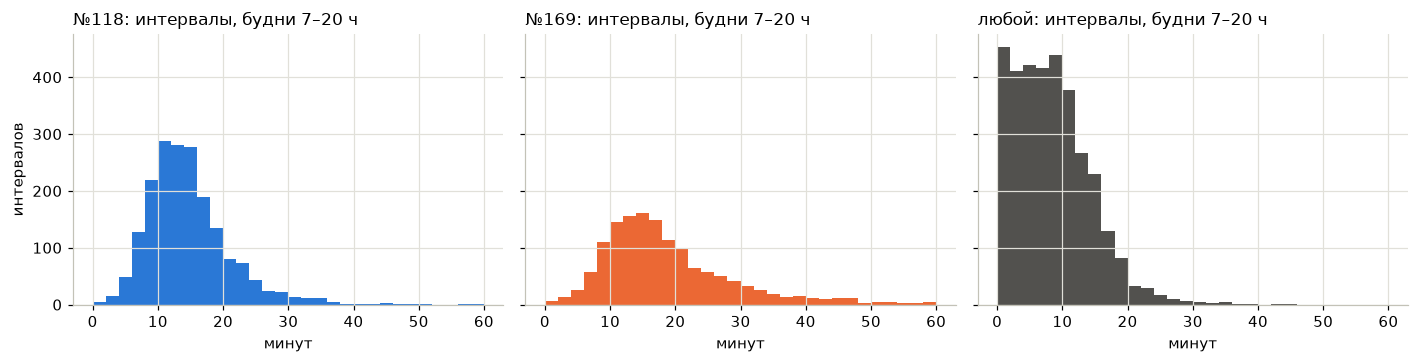

route        date   from     to      H
№169 3771    169  2026-09-22  17:56  19:40  103.9
     1438    169  2026-08-17  16:01  17:21   79.5
     2501    169  2026-09-04  18:04  19:22   78.2
     3272    169  2026-09-16  08:20  09:36   75.9
     1963    169  2026-08-26  15:15  16:30   75.8

In [32]:
def headways(buses):
    """Intervals between consecutive buses of the same day, without feed pauses inside."""
    b = buses.sort_values('t_a').copy()
    b['prev'] = b.groupby('date')['t_a'].shift()
    b['H'] = (b['t_a'] - b['prev']).dt.total_seconds() / 60
    b = b[b['H'].notna() & b['window'].notna()]
    return b[~overlaps_gap(b['prev'], b['t_a'])]


H = {'№118': headways(deps[deps['route'] == 118]),
     '№169': headways(deps[deps['route'] == 169]),
     'любой': headways(deps)}
summary = pd.concat({name: h.groupby('window', observed=True)['H'].agg(
    n='size', mean='mean', median='median', p90=lambda s: s.quantile(0.9), max='max',
    cv=lambda s: s.std() / s.mean()) for name, h in H.items()})
display(summary.round(2))

hist_colors = {'№118': COLORS[118], '№169': COLORS[169], 'любой': '#52514e'}
fig, axes = plt.subplots(1, 3, figsize=(13, 3.4), sharey=True)
for ax, (name, h) in zip(axes, H.items()):
    ax.hist(h['H'], bins=np.arange(0, 61, 2), color=hist_colors[name])
    ax.set(title=f'{name}: интервалы, будни 7–20 ч', xlabel='минут')
axes[0].set_ylabel('интервалов')
plt.tight_layout()
plt.show()
longest = pd.concat(H).nlargest(5, 'H')[['route', 'date', 'prev', 't_a', 'H']]
longest['from'] = longest['prev'].dt.tz_convert(TZ).dt.strftime('%H:%M')
longest['to'] = longest['t_a'].dt.tz_convert(TZ).dt.strftime('%H:%M')
display(longest[['route', 'date', 'from', 'to', 'H']].round(1))

**Ваш вывод:**

**Для преподавателя.**

- **Средние интервалы** растут к вечеру: у №118 — 13 / 15 / 16,5 минуты по окнам, у №169 — 17 / 20 / 21, у «любого» — 7,4 / 8,5 / 9,4.
- **Разброс большой:** CV ≈ 0,4–0,5 у №118, 0,5–0,65 у №169, ~0,7 у общего потока. Автобусы ходят неравномерно. У общего потока много интервалов в 0–2 минуты: автобусы двух маршрутов приходят почти одновременно.
- **Самые длинные интервалы** — до ~1 часа у №118 и до 1 ч 44 мин у №169, чаще во второй половине дня. Машины маршрута в это время были в ленте, но в нашем направлении не проезжали. Похоже на реальные разрывы в движении, а не на ошибку данных.
- **Про общий поток:** автобусы двух маршрутов не чередуются строго, иногда идут друг за другом, поэтому средний интервал общего потока не равен половине интервала одного маршрута.

**Задание 2.2. Сколько ждать: парадокс ожидания.**

1. Смоделируйте 20 000 пассажиров, приходящих в случайные моменты окна 07–10: `random_arrivals(7, 10)`. Найдите ожидание $W$ до ближайшего №118, №169 и «любого»: `next_bus(...)['wait_min']`.
2. Сравните среднее $W$ с половиной среднего интервала $E[H]/2$. Что больше и почему?
3. Проверьте на своих интервалах утреннего окна формулу $E[W] = \dfrac{E[H^2]}{2\,E[H]} = \dfrac{E[H]}{2}\,(1 + CV^2)$. Откуда она? Пассажир чаще попадает в длинный интервал: вероятность попасть в интервал пропорциональна его длине. Внутри интервала он ждёт в среднем половину его длины.
4. Какая доля пассажиров ждёт дольше 10 минут в каждом варианте?

In [33]:
arrivals = random_arrivals(7, 10, n=20_000, seed=1)
for name, buses in [('№118', deps[deps['route'] == 118]), ('№169', deps[deps['route'] == 169]), ('любой', deps)]:
    wait = next_bus(arrivals, buses)['wait_min']
    h = H[name].loc[H[name]['window'] == '07–10', 'H']
    print(f'{name}: среднее W = {wait.mean():.1f} мин | E[H]/2 = {h.mean() / 2:.1f} | '
          f'E[H²]/(2E[H]) = {(h ** 2).mean() / (2 * h.mean()):.1f} | P(W > 10) = {(wait > 10).mean():.2f}')

№118: среднее W = 7.8 мин | E[H]/2 = 6.4 | E[H²]/(2E[H]) = 7.6 | P(W > 10) = 0.28
№169: среднее W = 11.5 мин | E[H]/2 = 8.3 | E[H²]/(2E[H]) = 10.5 | P(W > 10) = 0.45
любой: среднее W = 5.5 мин | E[H]/2 = 3.7 | E[H²]/(2E[H]) = 5.3 | P(W > 10) = 0.14


**Ваш вывод:**

**Для преподавателя.**

- **Утро, среднее ожидание:** №118 ≈ 7,8 минуты при $E[H]/2$ ≈ 6,4 и формуле 7,6; №169 ≈ 11,5 при 8,3 и формуле 10,5; «любой» ≈ 5,5 при 3,7 и формуле 5,3.
- **Формула сходится с моделированием** с точностью около минуты. Остаток — краевые эффекты: пассажир, пришедший в 9:55, ждёт автобус уже следующего окна. Чем неравномернее интервалы (больше CV), тем сильнее ожидание превышает половину интервала.
- **Ждут дольше 10 минут:** ~28% пассажиров №118, ~45% №169, ~14% при «любом».

**Задание 2.3. Полное время: три стратегии.**

1. Для случайных моментов прихода в каждом окне дня посчитайте полное время $W + T$ (`next_bus(...)['total_min']`) для стратегий:
   - (а) жду только №118;
   - (б) жду только №169;
   - (в) сажусь в первый пришедший из двух.
2. Если автобус не пришёл за 60 минут, `total_min` пустое: считайте, что пассажир не успел.
3. Для запасов 20, 25, 30 и 40 минут найдите долю успевших по каждой стратегии и окну. Постройте CDF полного времени для утра: три кривые на одном графике.
4. Какая стратегия лучше? Совпадает ли ответ с выводом части 1? Почему?

,окно,стратегия,медиана W+T,успели за 20,успели за 25,успели за 30,успели за 40
0,07–10,ждать №118,22.38,0.36,0.64,0.82,0.97
1,07–10,ждать №169,24.85,0.31,0.51,0.66,0.86
2,07–10,первый пришедший,20.11,0.49,0.75,0.90,0.99
3,10–16,ждать №118,26.75,0.14,0.40,0.66,0.93
4,10–16,ждать №169,27.97,0.18,0.39,0.57,0.80
5,10–16,первый пришедший,23.68,0.27,0.58,0.81,0.96
6,16–20,ждать №118,32.95,0.04,0.19,0.38,0.72
7,16–20,ждать №169,37.32,0.04,0.14,0.27,0.57
8,16–20,первый пришедший,30.07,0.08,0.27,0.50,0.82


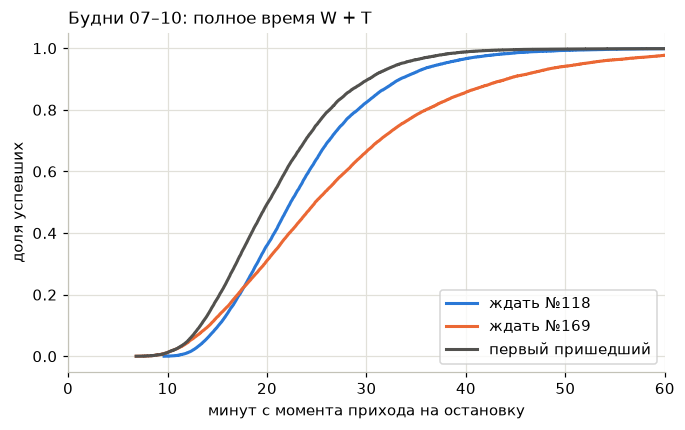

In [34]:
STRATEGIES = {'ждать №118': deps[deps['route'] == 118], 'ждать №169': deps[deps['route'] == 169], 'первый пришедший': deps}
rows, morning_totals = [], {}
for w, (h0, h1) in WINDOWS.items():
    arrivals = random_arrivals(h0, h1, n=20_000, seed=2)
    for name, buses in STRATEGIES.items():
        total = next_bus(arrivals, buses)['total_min']
        if w == '07–10':
            morning_totals[name] = total
        rows.append({'окно': w, 'стратегия': name, 'медиана W+T': total.fillna(np.inf).median(),
                     **{f'успели за {b}': (total <= b).mean() for b in [20, 25, 30, 40]}})
display(pd.DataFrame(rows).round(2))

fig, ax = plt.subplots(figsize=(7, 4))
for (name, total), color in zip(morning_totals.items(), [COLORS[118], COLORS[169], '#52514e']):
    xs = np.sort(total.dropna())
    ax.step(xs, np.arange(1, len(xs) + 1) / len(total), where='post', lw=2, color=color, label=name)
ax.set(xlim=(0, 60), xlabel='минут с момента прихода на остановку', ylabel='доля успевших',
       title='Будни 07–10: полное время W + T')
ax.legend(loc='lower right')
plt.show()

**Ваш вывод:**

**Для преподавателя.** Главный результат практикума: с учётом ожидания рекомендация меняется.

- **Первый пришедший выигрывает везде.** Утром за 20 минут от прихода успевают ≈ 49% при «первом пришедшем» против 36% у «жду №118» и 31% у «жду №169»; за 25 минут — 75% / 64% / 51%. Днём и вечером «первый пришедший» тоже впереди.
- **Среди стратегий «жду один маршрут» №118 теперь лучше или не хуже №169** почти везде. Исключение — день при запасе 20 минут: 18% у №169 против 14% у №118. №118 ходит чаще, и выигрыш в ожидании (2–4 минуты) больше проигрыша в скорости (до 2 минут).
- **С частью 1 это не противоречит.** Часть 1 отвечает на другой вопрос — «какой из двух стоящих автобусов выбрать». Ответ там по-прежнему «зависит от запаса».

**Задание 2.4. Что перевешивает: скорость или частота?**

1. Для каждой стратегии и окна разложите среднее полное время на среднее ожидание и среднее время в пути того автобуса, в который сел пассажир. Считайте только пассажиров, дождавшихся автобуса за 60 минут.
2. Что даёт больший вклад в разницу между стратегиями: скорость автобуса или то, как часто он ходит?
3. В части 1 №169 утром и днём часто выигрывал у №118 по времени в пути, а в части 2 проигрывает. Что именно перевешивает?

In [35]:
rows = []
for w, (h0, h1) in WINDOWS.items():
    arrivals = random_arrivals(h0, h1, n=20_000, seed=3)
    for name, buses in STRATEGIES.items():
        m = next_bus(arrivals, buses).dropna(subset=['t_a'])
        rows.append({'окно': w, 'стратегия': name, 'ожидание W': m['wait_min'].mean(),
                     'поездка T': (m['total_min'] - m['wait_min']).mean(), 'W + T': m['total_min'].mean(),
                     'не дождались за 60 мин': 1 - len(m) / len(arrivals)})
display(pd.DataFrame(rows).round(2))

,окно,стратегия,ожидание W,поездка T,W + T,не дождались за 60 мин
0,07–10,ждать №118,7.82,15.77,23.59,0.00
1,07–10,ждать №169,11.65,15.70,27.35,0.00
2,07–10,первый пришедший,5.50,15.63,21.13,0.00
3,10–16,ждать №118,8.70,19.26,27.96,0.00
4,10–16,ждать №169,13.02,17.88,30.90,0.00
5,10–16,первый пришедший,6.17,18.62,24.79,0.00
6,16–20,ждать №118,11.69,23.45,35.14,0.01
7,16–20,ждать №169,13.94,25.27,39.21,0.04
8,16–20,первый пришедший,7.70,24.18,31.87,0.00


**Ваш вывод:**

**Для преподавателя.**

- **Поездка:** среднее время в пути у разных стратегий различается не больше чем на 2 минуты, утром — почти не различается.
- **Ожидание:** у «жду №169» оно на 2–4 минуты дольше, чем у «жду №118», а «первый пришедший» экономит ещё 2–4 минуты. Вечером около 4% пассажиров №169 вообще не дожидаются автобуса за час, в основном под конец движения.
- **Вывод:** перевешивает частота, а не скорость. «Первый пришедший» сокращает ожидание почти вдвое и почти ничего не теряет в поездке.

**Задание 2.5\*. Идеальный выбор и устойчивость вывода.**

1. **Идеальный выбор задним числом.** Для каждого пассажира найдите среди автобусов, прошедших A в ближайшие 60 минут, тот, что **раньше всех доехал** до «Азия Молла». Насколько эта стратегия лучше «первого пришедшего»? Что это говорит о ценности знания «какой маршрут сейчас быстрее»? Подсказка: `np.searchsorted` по отсортированным `t_a` даёт границы автобусов для каждого прихода.
2. **Устойчивость.** Исключите дни, когда у какого-либо маршрута был интервал длиннее 60 минут, и повторите задание 2.3 для одного окна. Меняется ли вывод?

In [36]:
def best_in_hindsight(arrivals, buses, horizon_min=60):
    """Total time with the bus that reaches B first among those passing A within the horizon."""
    order = buses.sort_values('t_a')
    t_a = order['t_a'].dt.tz_convert(None).to_numpy()
    t_b = order['t_b'].dt.tz_convert(None).to_numpy()
    s = arrivals.dt.tz_convert(None).to_numpy()
    lo = np.searchsorted(t_a, s)
    hi = np.searchsorted(t_a, s + np.timedelta64(horizon_min, 'm'))
    minutes = [(t_b[i:j].min() - si) / np.timedelta64(1, 'm') if j > i else np.nan for i, j, si in zip(lo, hi, s)]
    return pd.Series(minutes)


arrivals = random_arrivals(7, 10, n=20_000, seed=2)
first = next_bus(arrivals, deps)['total_min']
best = best_in_hindsight(arrivals, deps)
for b in [20, 25, 30]:
    print(f'успели за {b} мин: первый пришедший {(first <= b).mean():.2f}, идеальный выбор {(best <= b).mean():.2f}')

long_days = pd.concat(H.values()).query('H > 60')['date'].unique()
stable = deps[~deps['date'].isin(long_days)]
print('дней с интервалом > 60 мин:', len(long_days))
for name, buses in [('ждать №118', stable[stable['route'] == 118]), ('ждать №169', stable[stable['route'] == 169]),
                    ('первый пришедший', stable)]:
    total = next_bus(arrivals[~arrivals.dt.tz_convert(TZ).dt.strftime('%Y-%m-%d').isin(long_days)].reset_index(drop=True), buses)['total_min']
    print(f'{name}: успели за 25 мин {(total <= 25).mean():.2f}')

успели за 20 мин: первый пришедший 0.49, идеальный выбор 0.52
успели за 25 мин: первый пришедший 0.75, идеальный выбор 0.78
успели за 30 мин: первый пришедший 0.90, идеальный выбор 0.91
дней с интервалом > 60 мин: 18
ждать №118: успели за 25 мин 0.67


ждать №169: успели за 25 мин 0.55
первый пришедший: успели за 25 мин 0.78


**Ваш вывод:**

**Для преподавателя.**

- **Идеальный выбор** лучше «первого пришедшего» всего на 1–3 п.п. Знание «какой маршрут быстрее прямо сейчас» почти ничего не даёт: ожидание важнее.
- **Где информация полезнее:** приложение с картой полезно другим — позволяет прийти к остановке вовремя, то есть уменьшить $W$. Но это уже выход за наше допущение о случайном приходе.
- **Устойчивость:** интервал длиннее часа хотя бы раз был в 18 из 37 дней. Это обычное явление, а не редкий сбой, и исключать такие дни — жёсткая проверка. Если всё же исключить, доли вырастают на 3–4 п.п., а порядок стратегий сохраняется.

**Задание 2.6. Допущения и границы вывода.**

Ответьте словами:

1. Какие допущения сделаны в части 2? Как изменится ответ, если пассажир смотрит приложение и выходит к остановке к приходу автобуса?
2. Что будет, если автобус переполнен и в него не сесть? Если автобус проезжает остановку, не останавливаясь?
3. Что из этого можно увидеть в наших данных, а что нельзя?
4. Как изменился бы вывод, если бы №169 ходил так же часто, как №118?

**Ваш ответ:**

**Для преподавателя.**

- **Допущения:** случайный приход; посадка всегда возможна; учитываются только автобусы, доехавшие до B; час ожидания.
- **С приложением** ожидание перестаёт быть случайным, и на первый план выходит время в пути. Тогда ближе к ответу части 1.
- **Заполненности и того, остановился ли автобус, в данных нет.** Видно только, что автобус проехал точку остановки.
- **Если бы №169 ходил так же часто,** выбор определялся бы временем в пути, как в части 1: утром и днём при малом запасе №169, вечером №118.

**Записка к части 2** (5–7 предложений). Человек только что подошёл к «Моссовету» и торопится в «Азия Молл». Что ему посоветовать? Приведите доли для двух-трёх запасов времени. Объясните парадокс ожидания своими словами. Перечислите допущения и где вывод может не сработать.

**Ваша записка:**

# Что сдать

- Ноутбук с решёнными заданиями 1.1–1.7 и 2.1–2.4, 2.6. Задания со звёздочкой — по желанию.
- Записку к части 1 и записку к части 2.
- В каждой записке: событие, доли, модель и почему она расходится с данными, допущения, к каким поездкам относится вывод.